In [10]:
# Importações
import sys
import os
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from datetime import timedelta
import matplotlib.pyplot as plt

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed
from src.utils.experiment_utils import find_experiment_by_name

# Importar as funções
from src.result_analysis.plots import ( 
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes
)

from src.result_analysis.extract_flow_extremes import analyze_flow_extremes
from src.result_analysis.metrics import compute_metrics_by_event_type
from src.result_analysis.plots import plot_metrics_by_horizon_comparison, plot_predictions_extremes, plot_forecast_horizons_analysis

from src.result_analysis.metrics import (
    compute_flow_metrics,
    print_metrics_summary
)

from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_dataset_for_training_validation, create_dataset_for_inference, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
    compute_flow_metrics,
    print_metrics_summary,
    plot_predictions_with_context,
    plot_metrics_by_horizon
)

from src import save_predictions, save_plot

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed


In [11]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]
window_stride = data_config['split_config']['window_stride']
train_ratio = data_config['split_config']['train_ratio']
test_ratio = data_config['split_config']['test_ratio']
val_ratio = data_config['split_config']['val_ratio']
horizon = data_config["horizon"]
reference_dates = data_config["reference_dates"]
experiment_name = data_config["experiment_name"]

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados


In [12]:
# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


📊 Carregando dados processados...
✓ Dados carregados: 6330 dias
  Período: 1995-01-01 a 2012-04-30
  Colunas: 67


In [13]:
## Caso queira passar manualmente o caminho para um modelo ## Se for modelo antigo deve ser usar load_checkpoint_legacy
#model_path = Path(r"C:/Users/emily/Documents/GitHub/Mini-curso-GitHub-Leo/outputs/experiments/exp_012_Improve_model_performance_climate_proj_fix_no_flow/model/model_climate_proj_fix.pth")

# Detecta automaticamente o último experimento pelo nome definido no data_config
exp_path = find_experiment_by_name(experiment_name)
model_dir = exp_path / "model"
pth_files = sorted(model_dir.glob("*.pth"))
if not pth_files:
    raise FileNotFoundError(f"Nenhum modelo encontrado em {model_dir}. Salve o modelo com save_checkpoint primeiro.")
model_path = pth_files[0]

# Configuração
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregar Modelo e Metadados
print(f"Carregando checkpoint: {model_path}")
model, meta = load_checkpoint(model_path, device=DEVICE)


Carregando checkpoint: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\model\exp_27_diagnostic_base_exp22.pth
⚠️ Aviso: Carregamento seguro falhou (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiar

In [14]:
ds_full = create_dataset_for_training_validation(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    train_indices=np.array([0]),  # Dummy (será substituído)
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=[],
    static_keys=static_keys,
    horizon=horizon,
    use_last_days_as_forecast=False,  # ✅ NÃO RESERVAR
    window_stride=1,  # ✅ SEMPRE 1 PARA TESTE/INFERÊNCIA
    forcings="P"
)

In [15]:
# 4. Injetar scalers do modelo treinado
ds_full.flow_scalers = meta["flow_scalers"]
ds_full.climate_scalers = meta["climate_scalers"]
ds_full.static_scalers = meta["static_scalers"]

print(f"📊 Dataset completo: {len(ds_full)} amostras")

train_ds, val_ds, test_ds = create_temporal_split_with_gap(
    dataset=ds_full,
    train_ratio=train_ratio,   # 95% treino
    val_ratio=val_ratio,    # 2.5% validação
    test_ratio=test_ratio,   # 2.5% teste
    gap=128
)

print(f"✂️ Split criado:")
print(f"  Validação/Teste: {len(test_ds)} amostras")

# 7. DataLoader
dl_test = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=custom_collate_fn
)

print(f"✅ DataLoader criado com {len(dl_test)} batches")

📊 Dataset completo: 6286 amostras
✂️ Split criado:
  Validação/Teste: 315 amostras
✅ DataLoader criado com 5 batches


In [16]:
# 7. Executar Previsão
print("🔮 Gerando previsões")
preds, obs, baseline, g_seq, dates, _ = predict_autoregressive(
    model=model,
    loader=dl_test, # Agora carrega apenas o teste
    decoder_history=meta["decoder_history"],
    decoder_horizon=meta["decoder_horizon"],
    scalers=meta["flow_scalers"],
    stations=data_config["stations"],
    clamp_non_negative=True,
    device=DEVICE)

🔮 Gerando previsões


In [17]:
# Métricas Gerais
metrics = compute_flow_metrics(
    preds=preds,
    obs=obs,
    stations=meta["stations"], # Use meta["stations"] aqui
    baseline_last=baseline
)

print_metrics_summary(metrics)
#save_metrics(metrics, experiment_name)

💾 Métricas salvas (JSON): C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\raw\metrics.json
💾 Métricas salvas (CSV): C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\raw\metrics.csv
RESUMO DAS MÉTRICAS POR ESTAÇÃO
📍 Estação 10100000
------------------------------------------------------------
  Overall:
    RMSE:       2154.794 m³/s
    MAE:        1435.020 m³/s
    MAPE:       5.21%
    R²:         0.9736
    NSE:        0.9736
    KGE:        0.9223
    Skill RMSE: 0.3353
Macro (ponderado por horizonte):
    RMSE:       1941.489 m³/s
    MAE:        1435.020 m³/s
    MAPE:       5.21%
    R²:         0.9741
    NSE:        0.9741
📍 Estação 13150000
------------------------------------------------------------
  Overall:
    RMSE:       2000.674 m³/s
    MAE:        1359.307 m³/s


📊 Criando gráfico principal (Teste: D+1 e D+15)...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d1_dmax.png


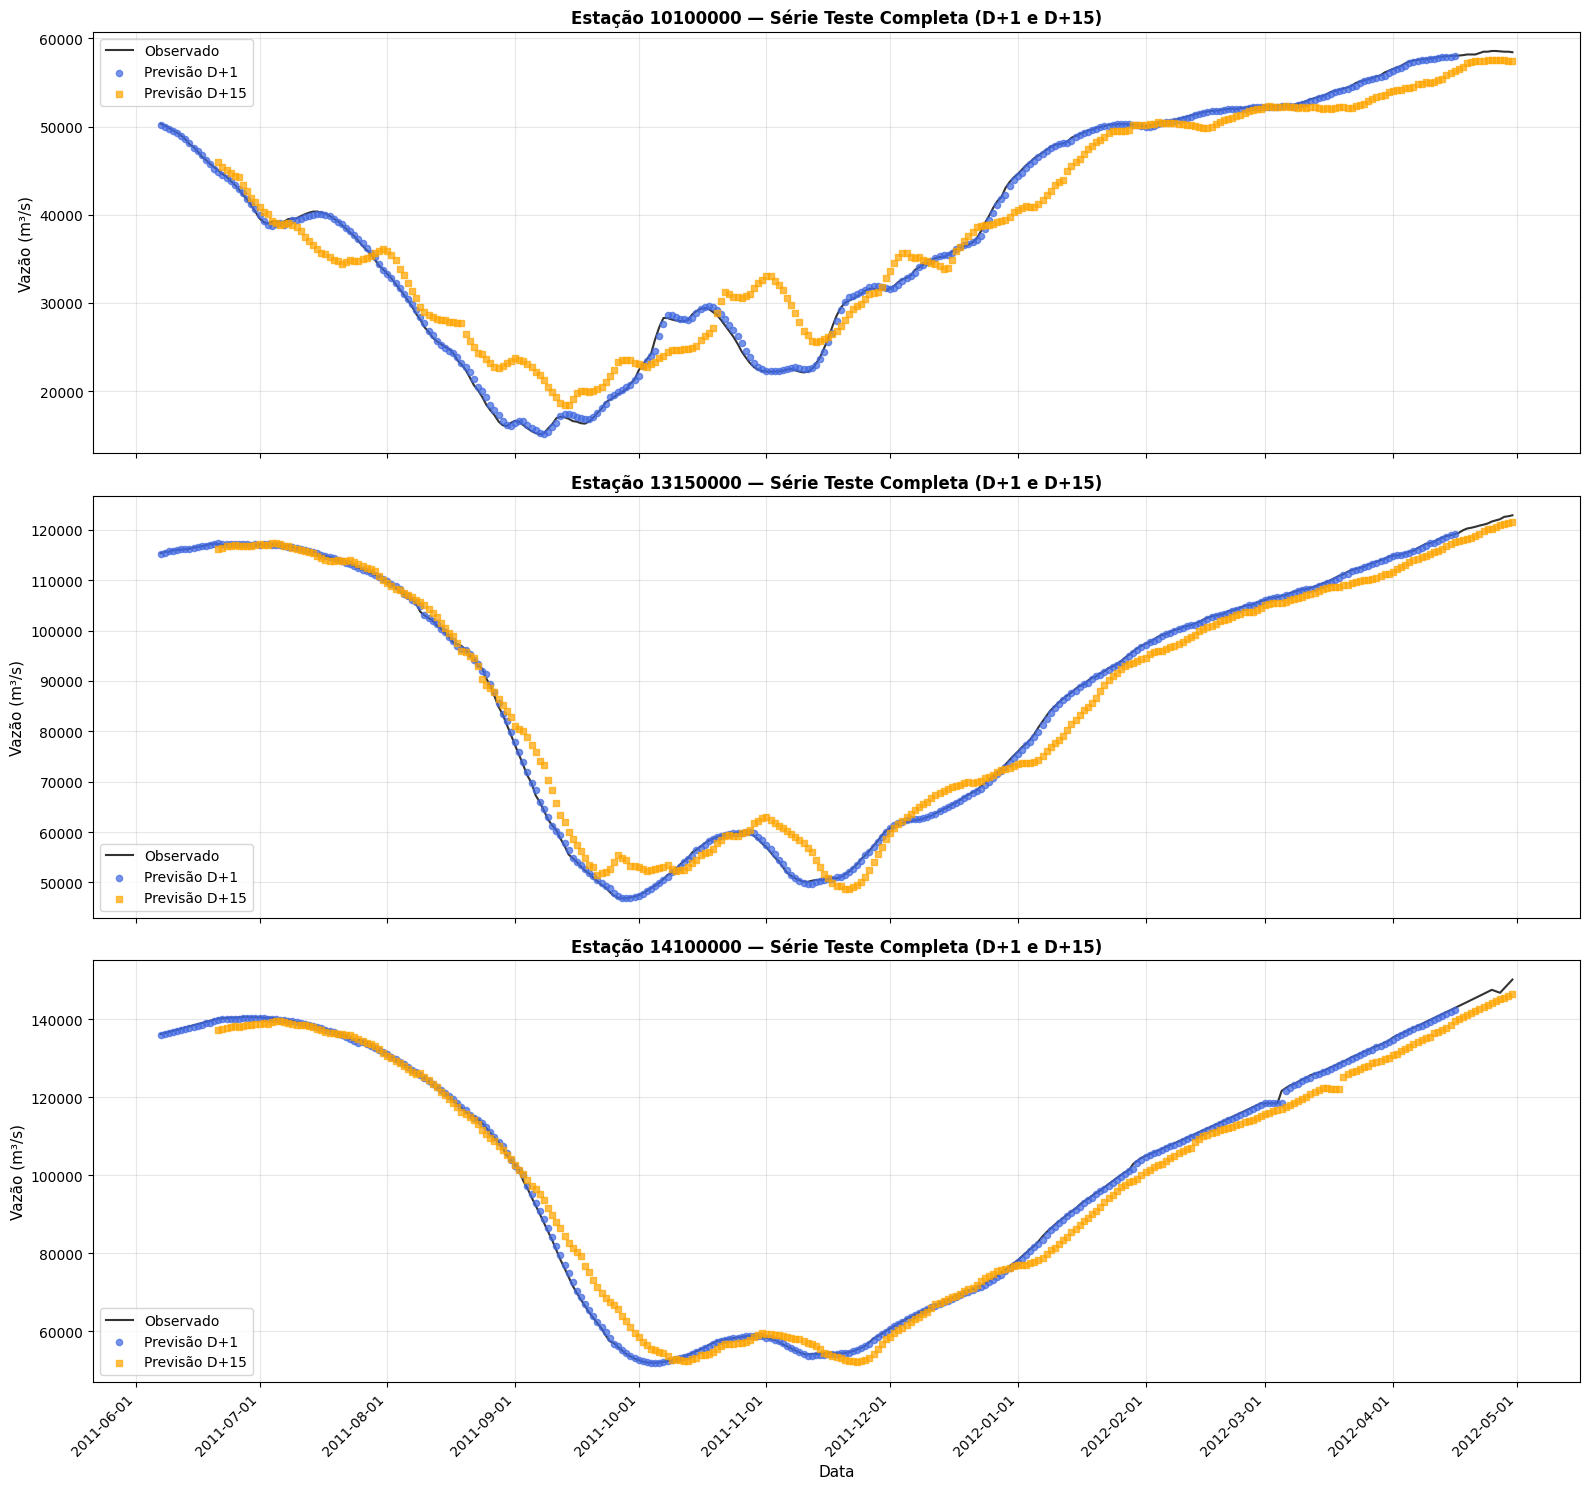


📊 Criando 15 gráficos individuais (D+1 até D+15)...
  → Criando gráfico D+1...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d1.png


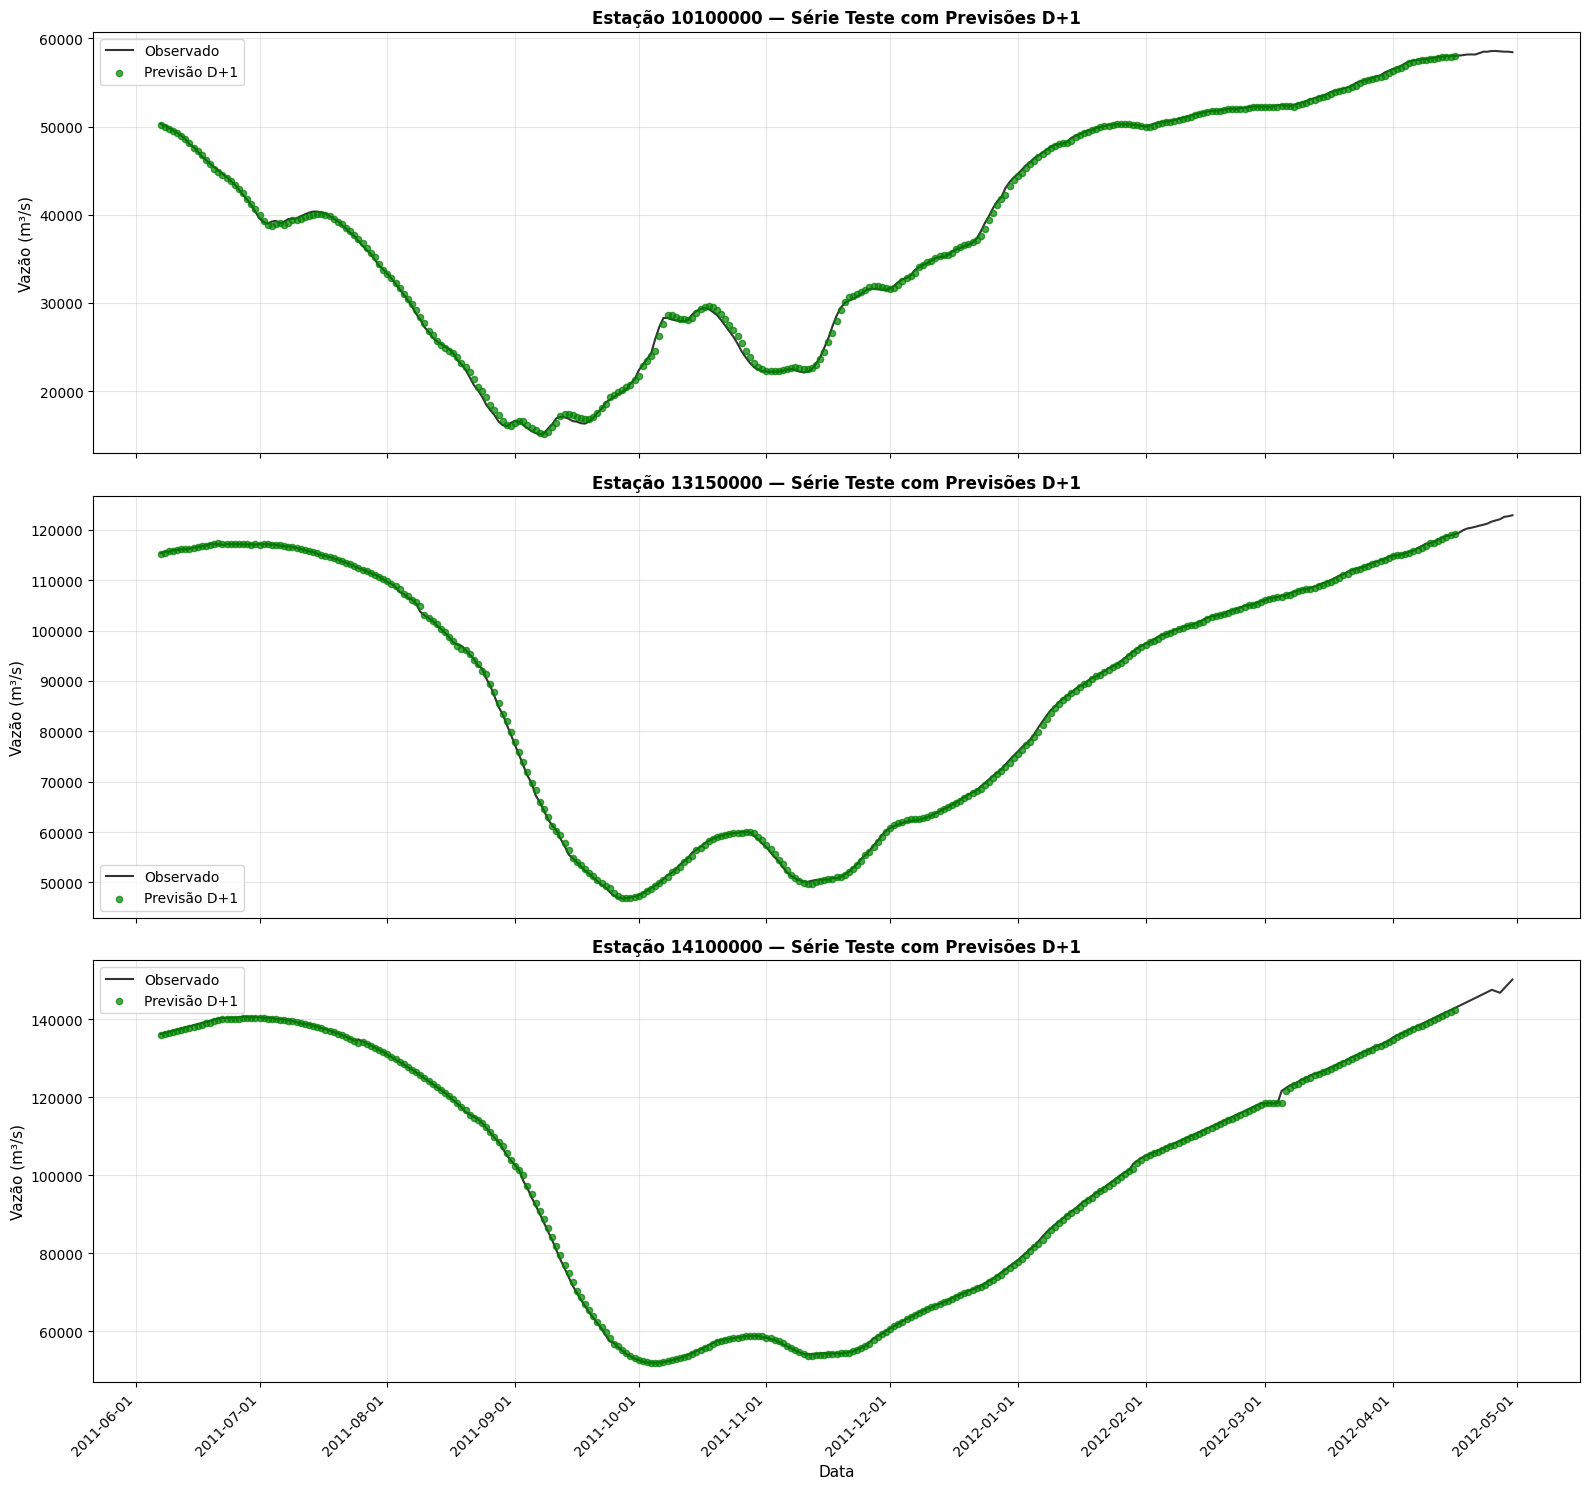

  → Criando gráfico D+2...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d2.png


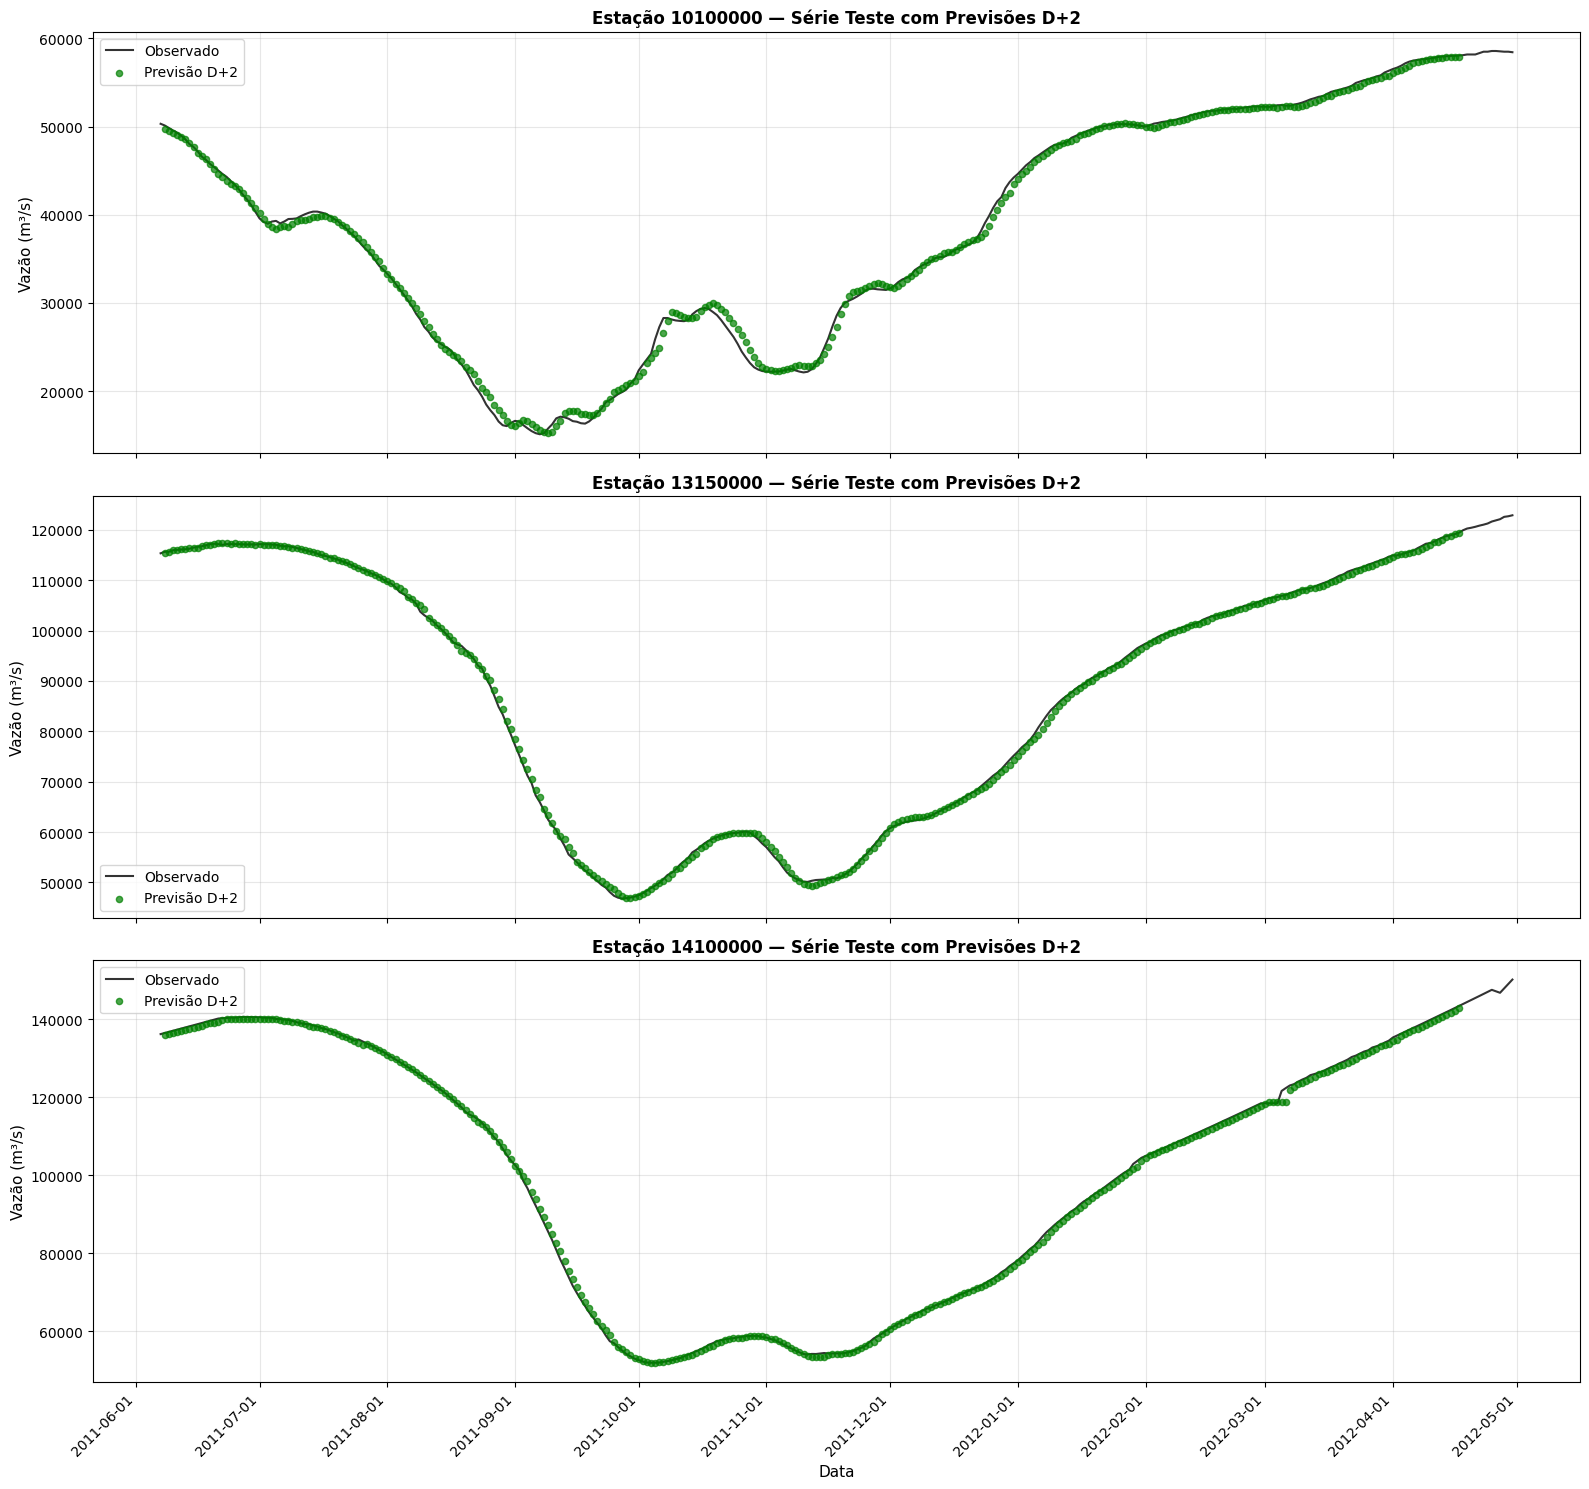

  → Criando gráfico D+3...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d3.png


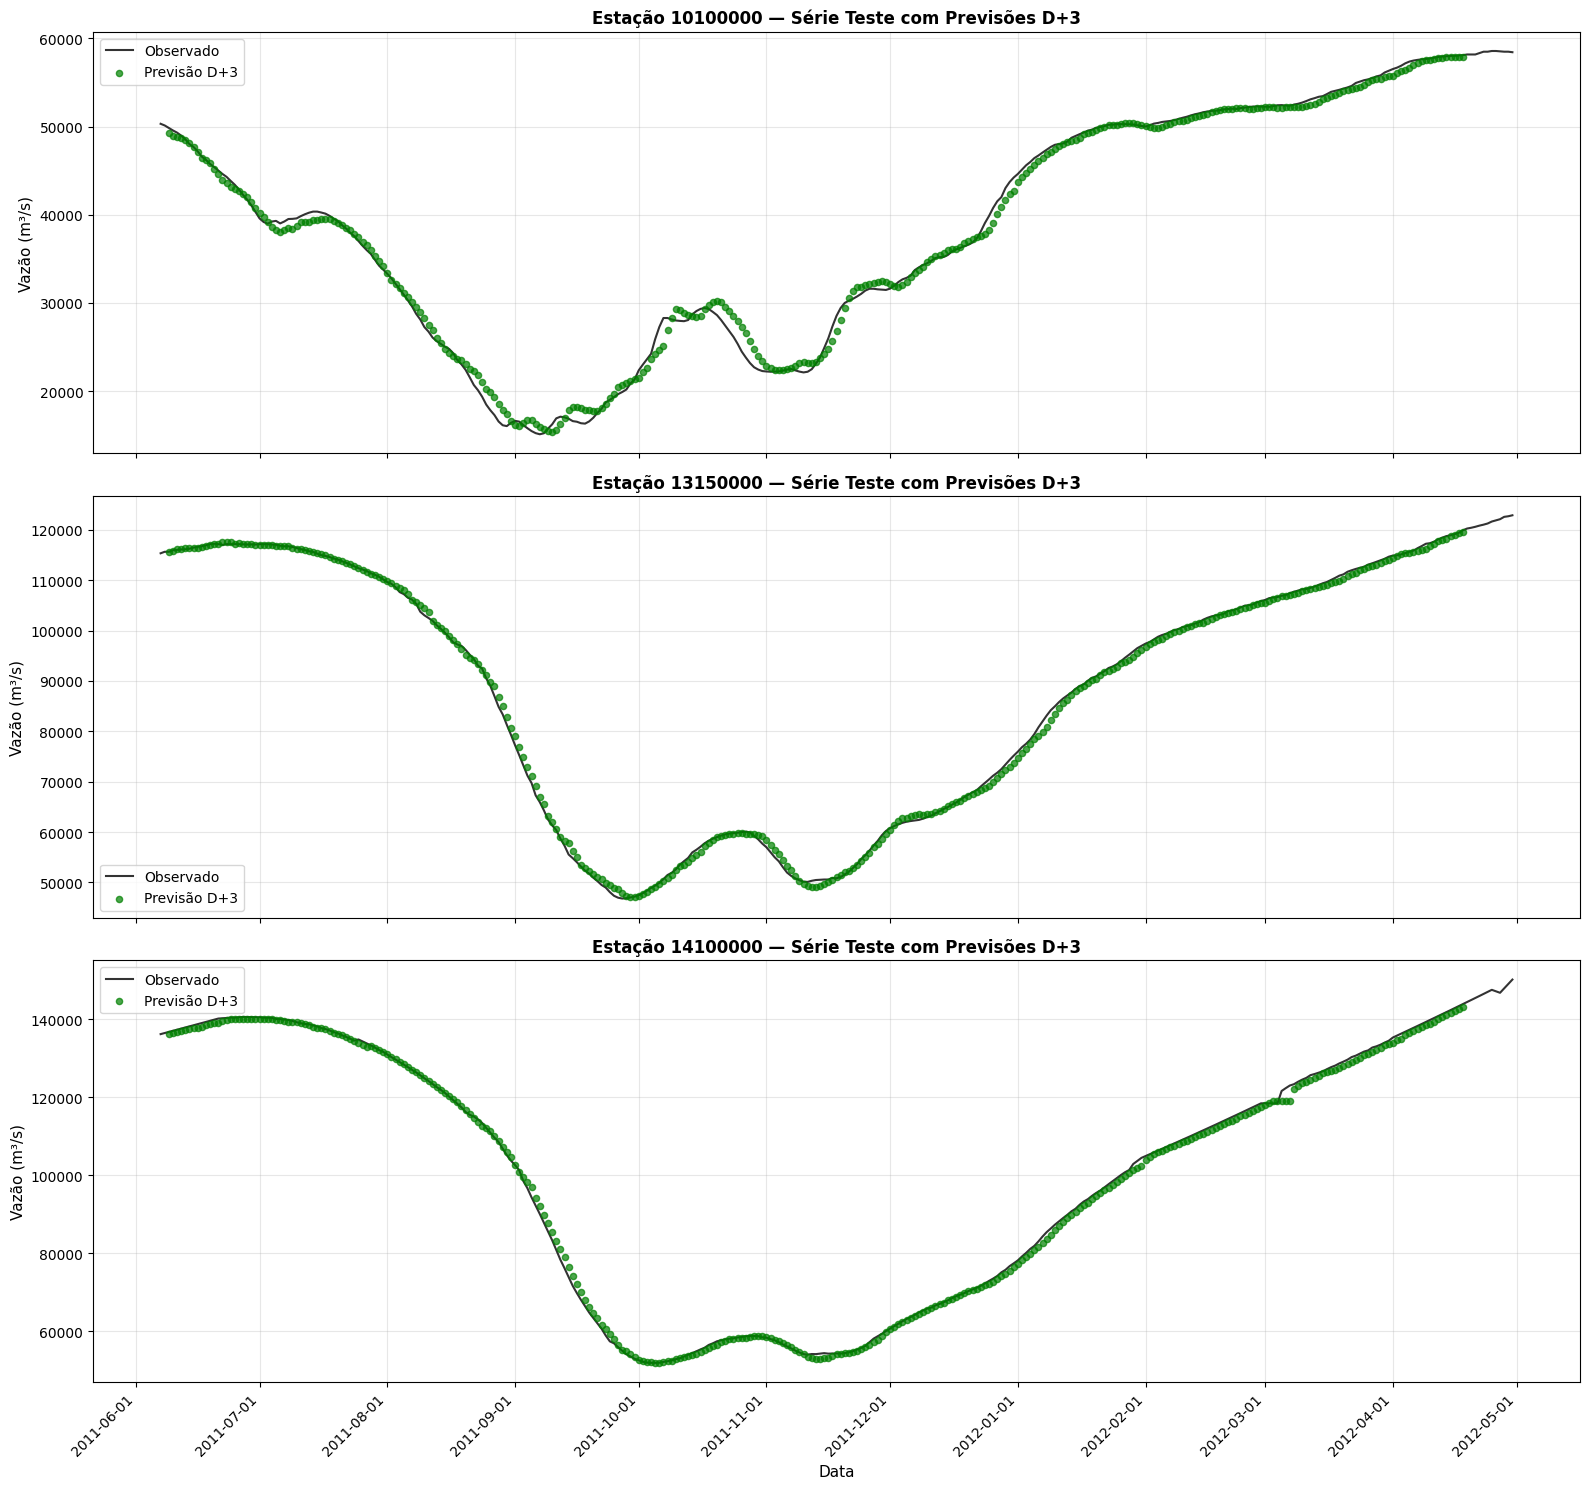

  → Criando gráfico D+4...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d4.png


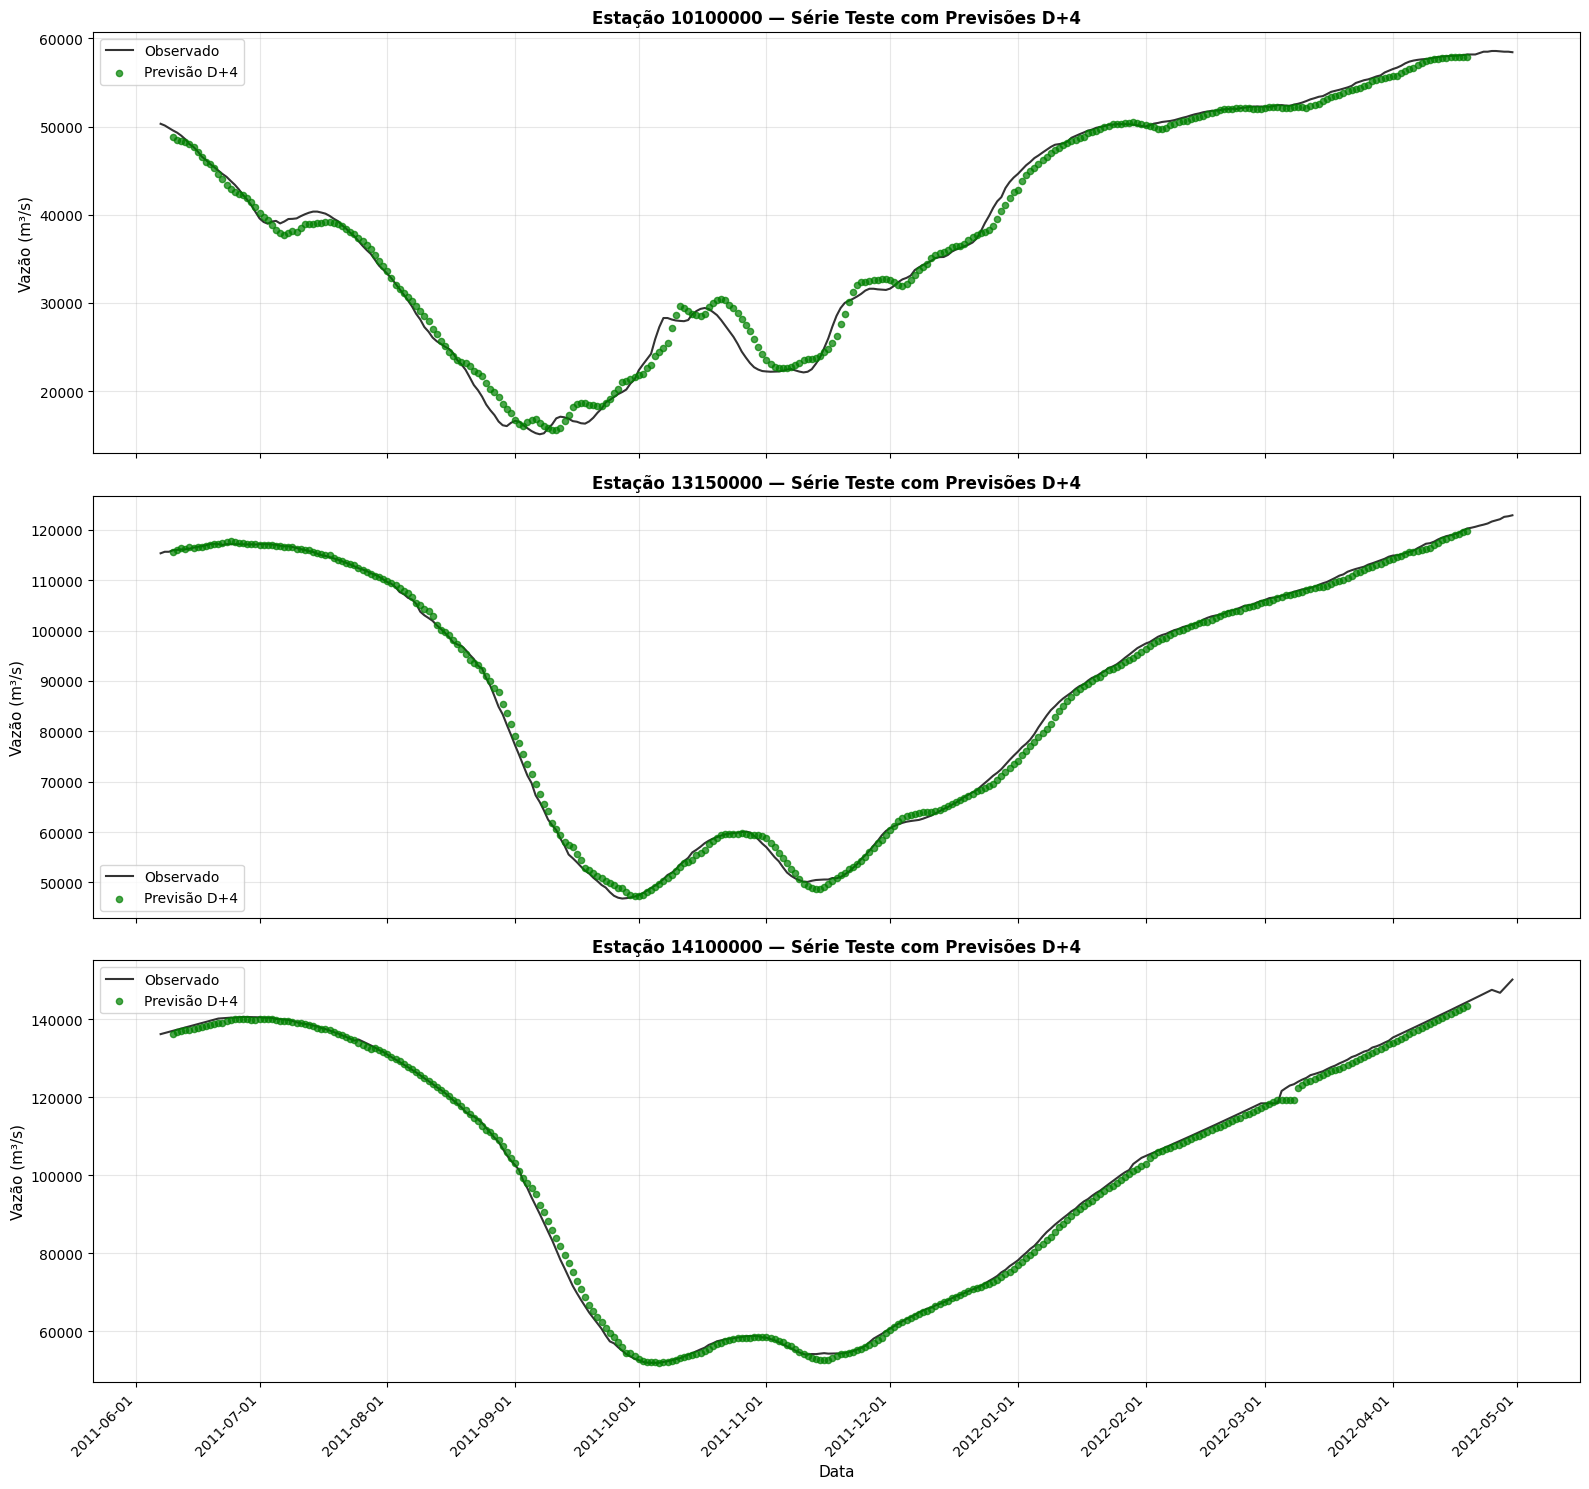

  → Criando gráfico D+5...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d5.png


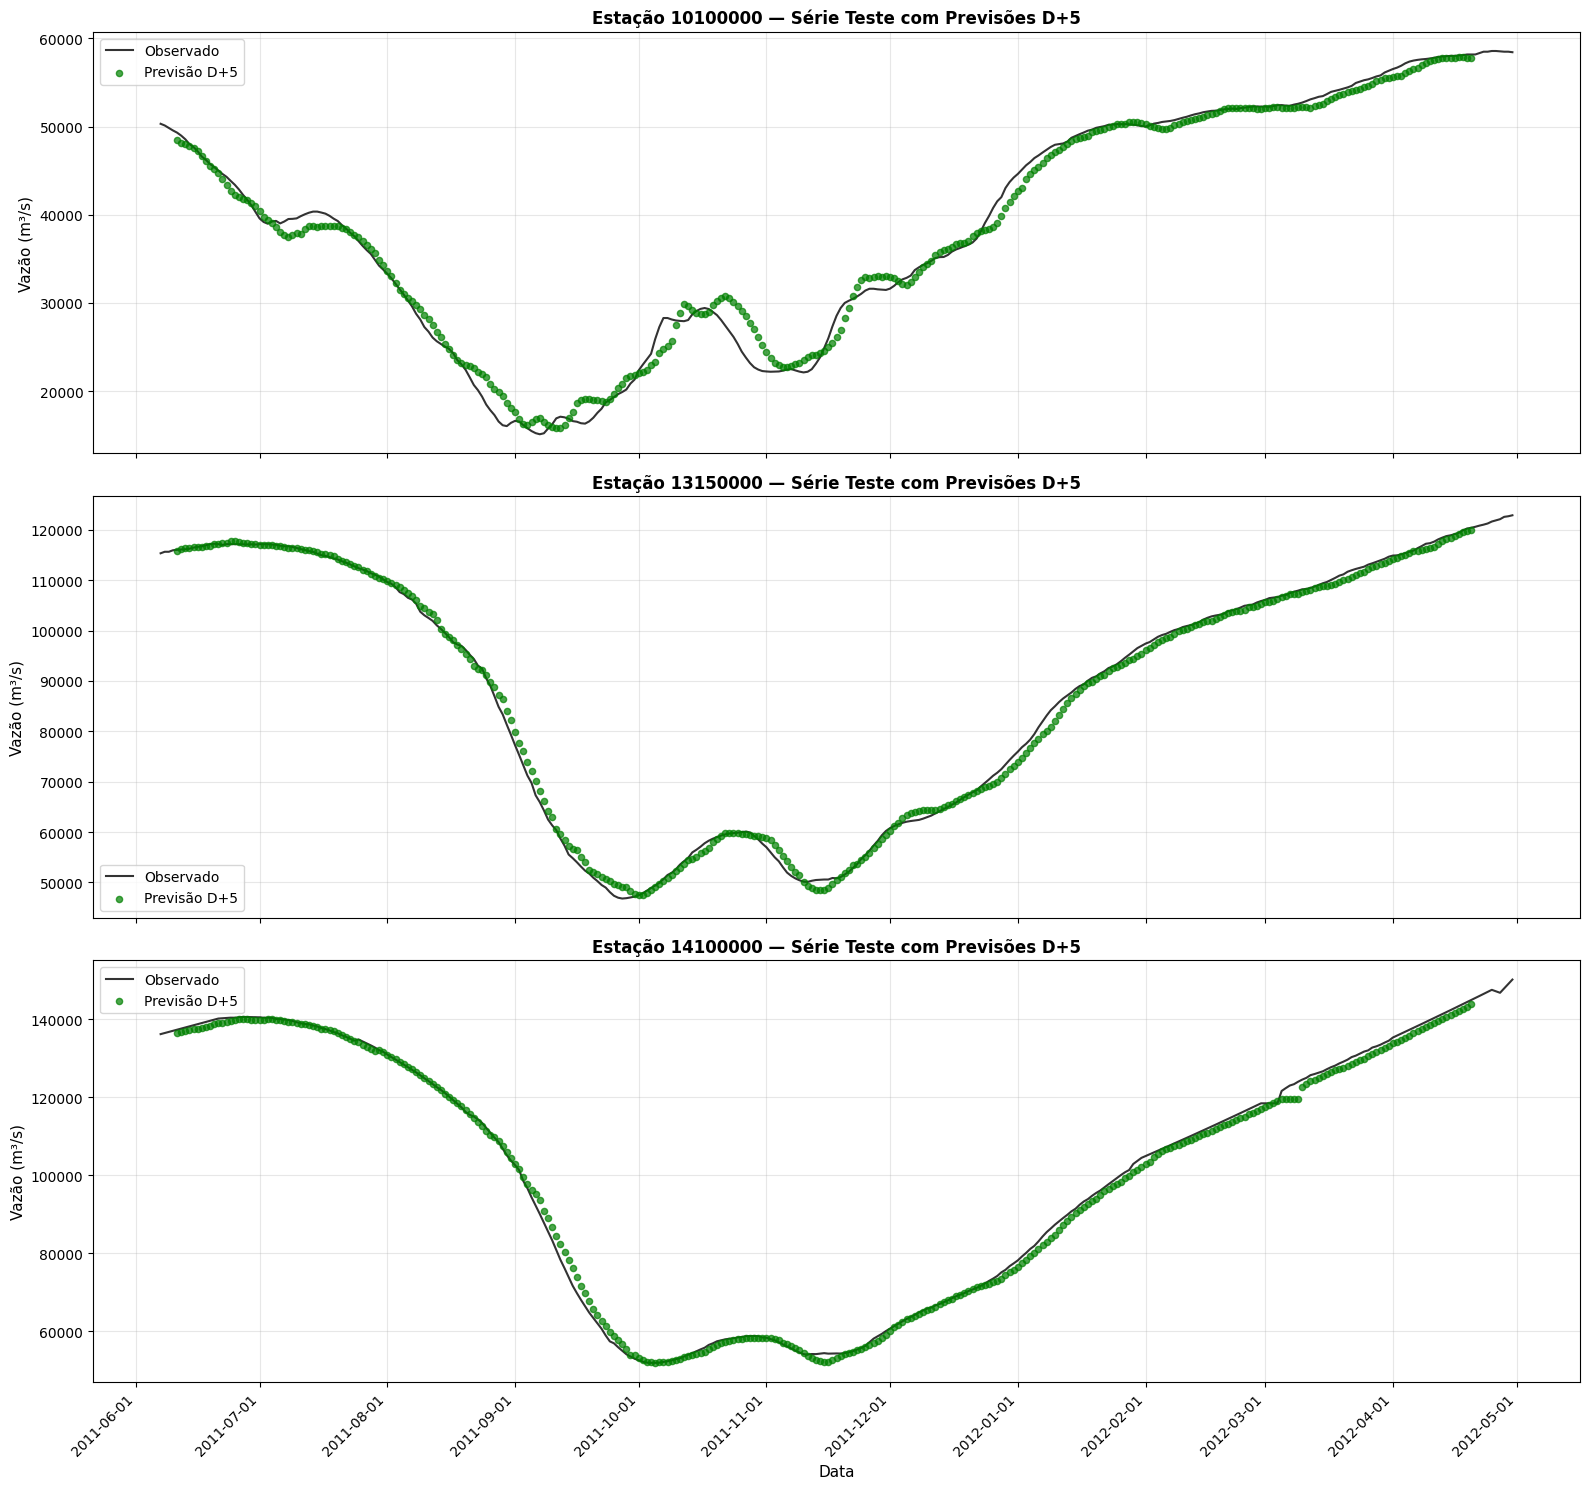

  → Criando gráfico D+6...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d6.png


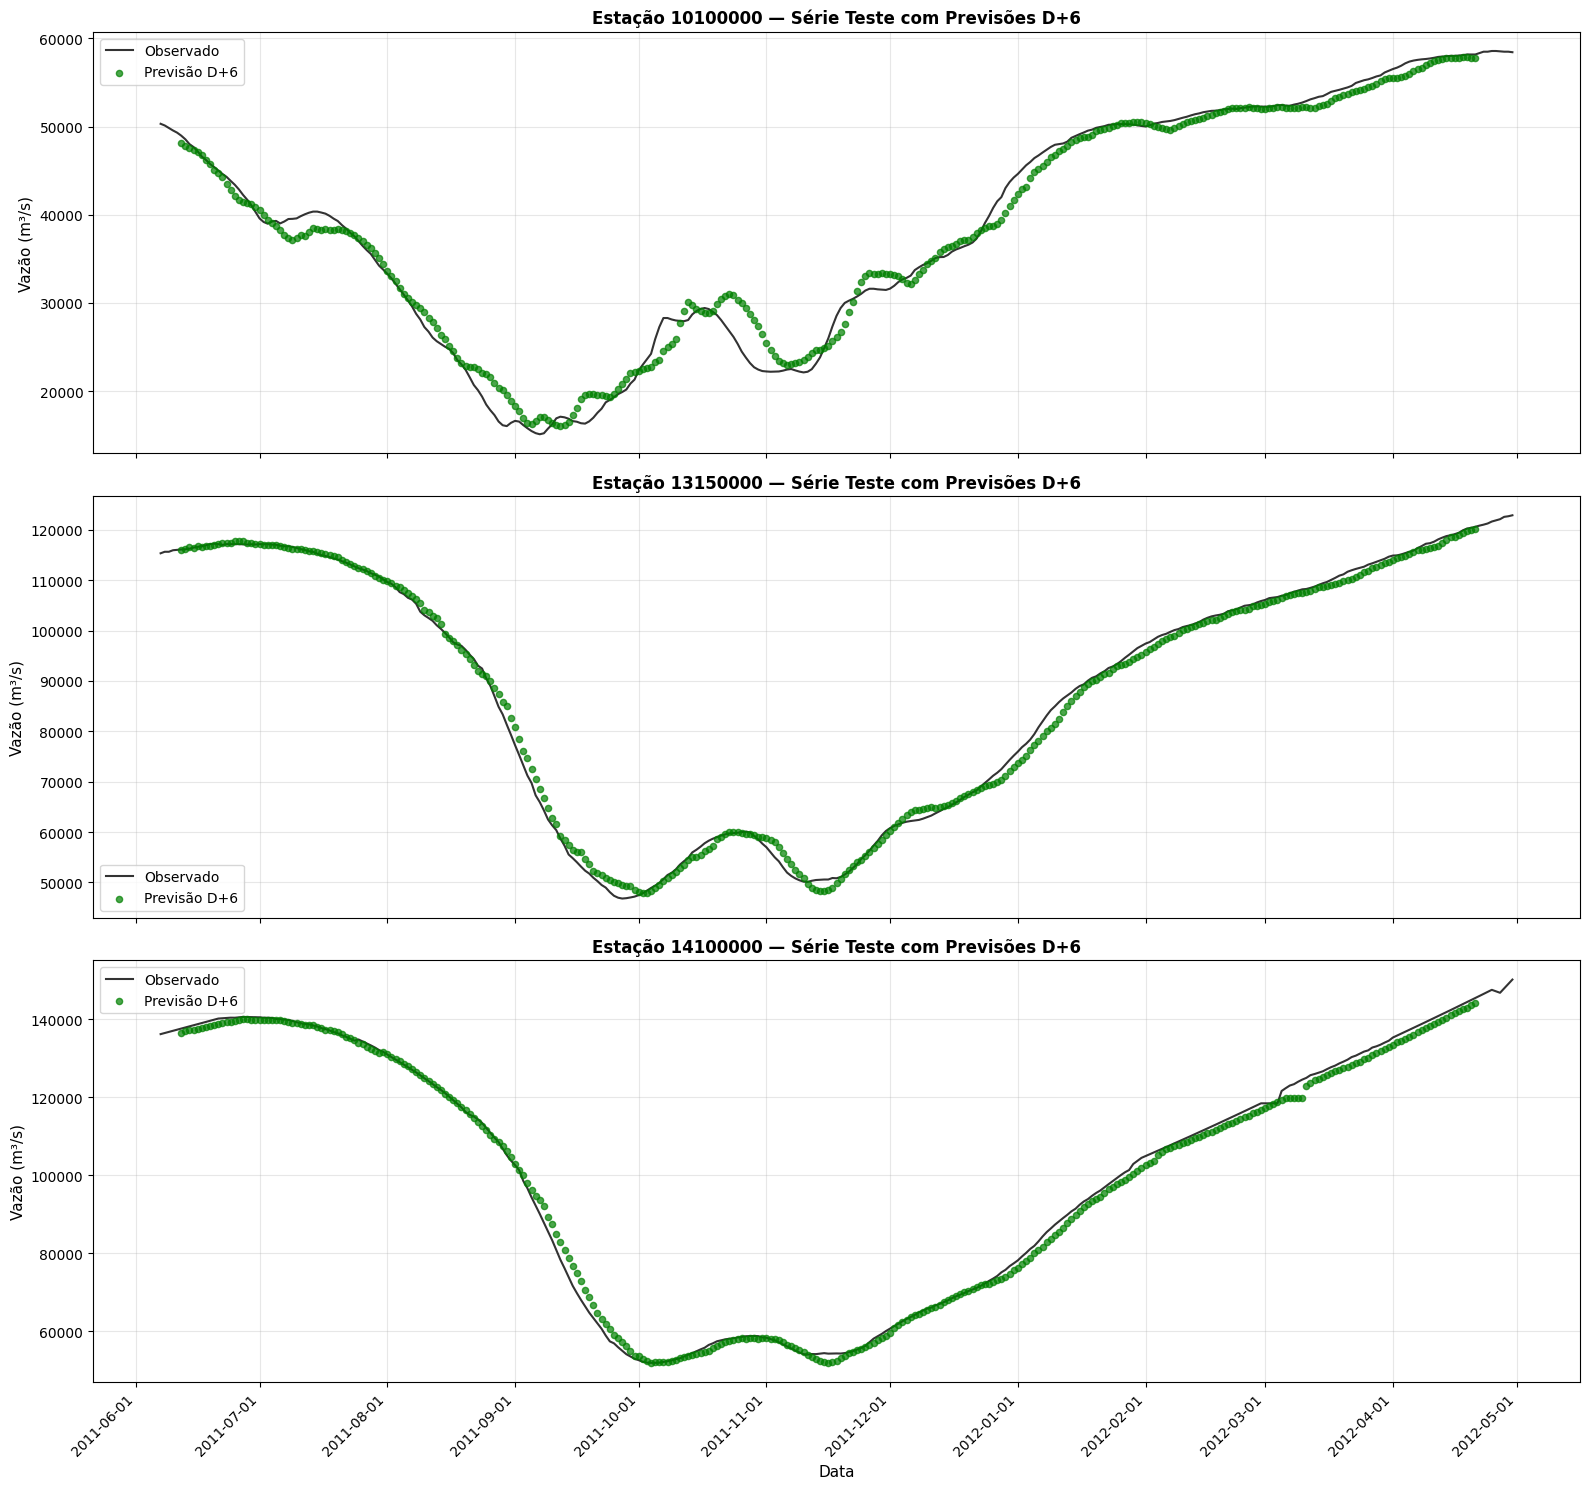

  → Criando gráfico D+7...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d7.png


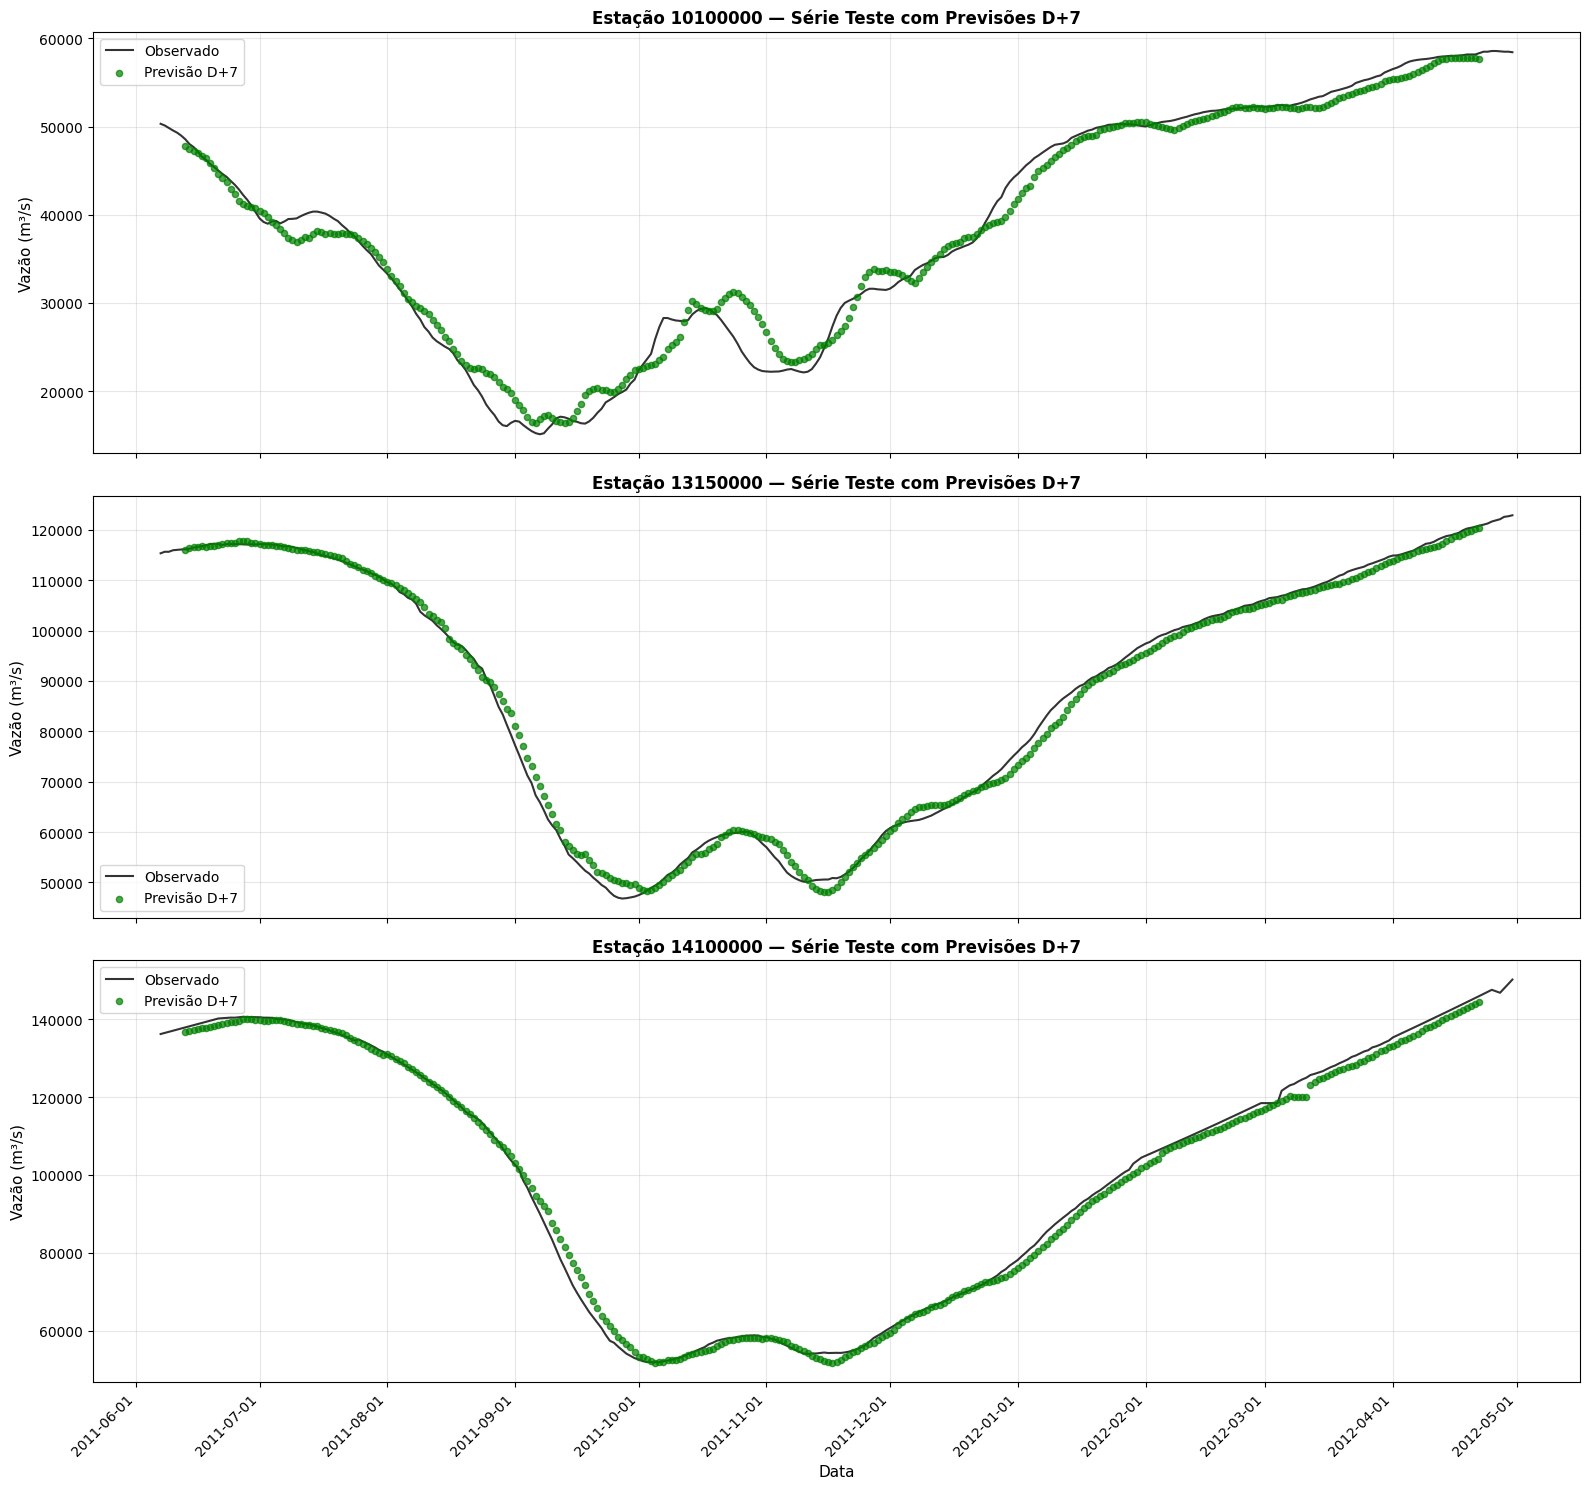

  → Criando gráfico D+8...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d8.png


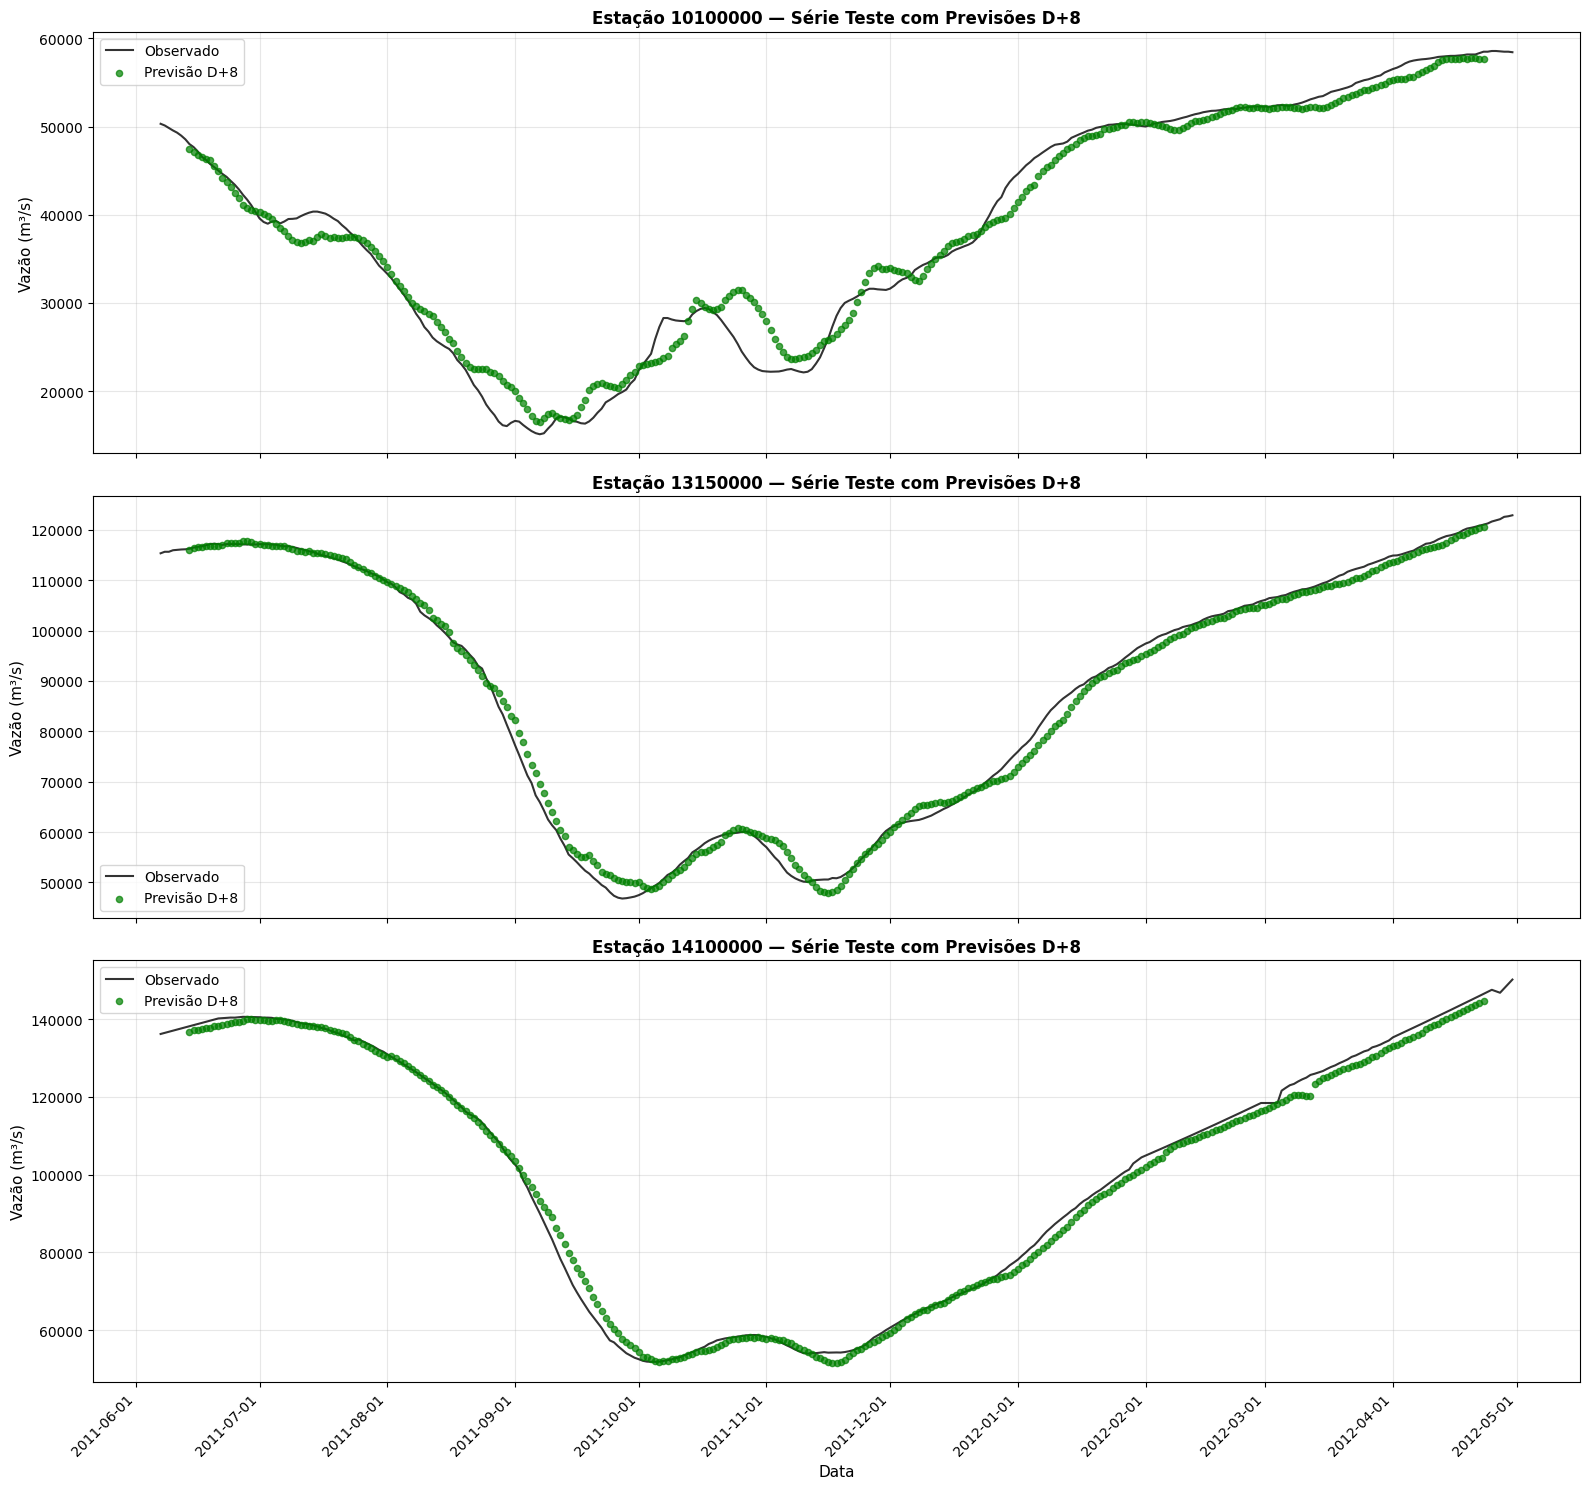

  → Criando gráfico D+9...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d9.png


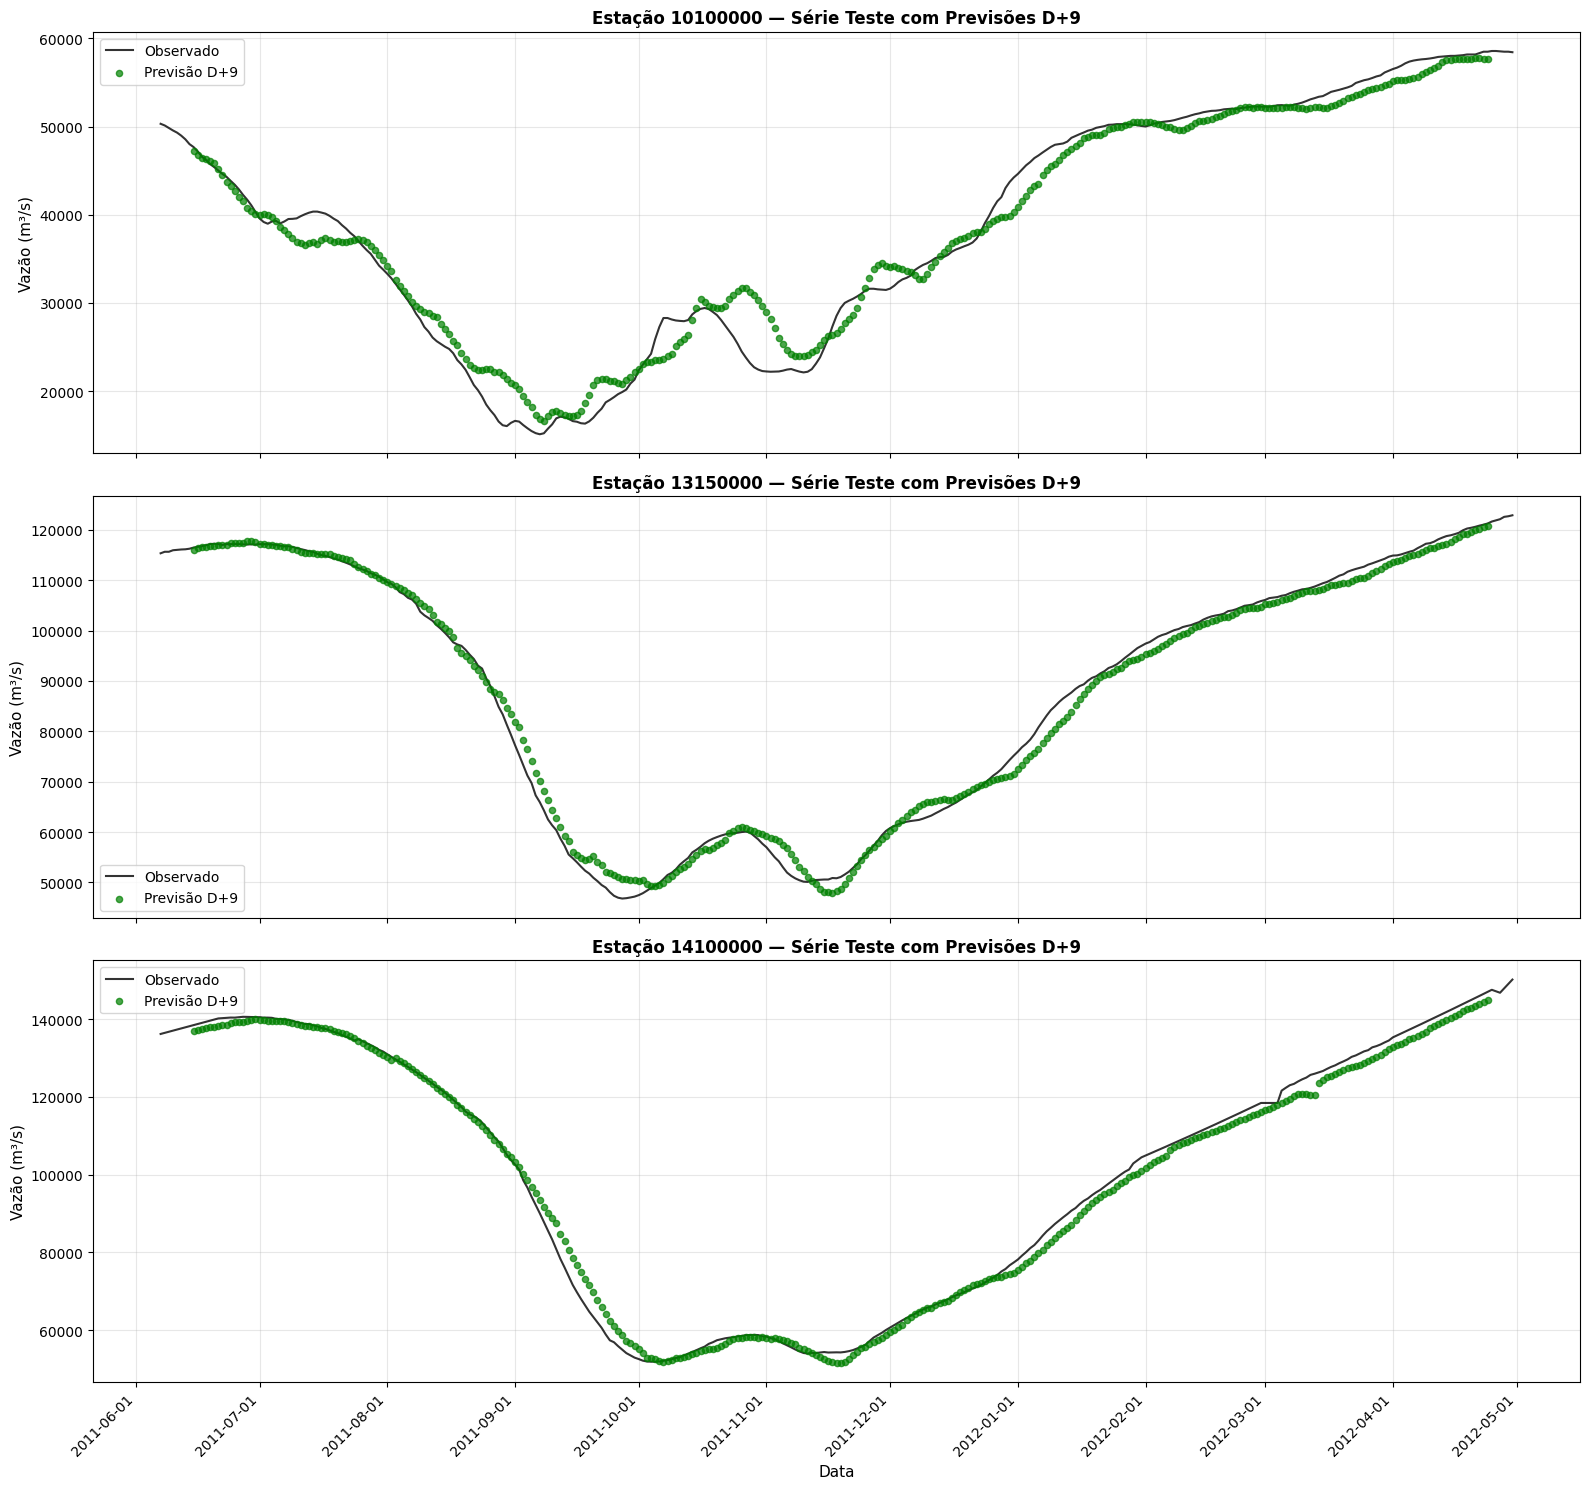

  → Criando gráfico D+10...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d10.png


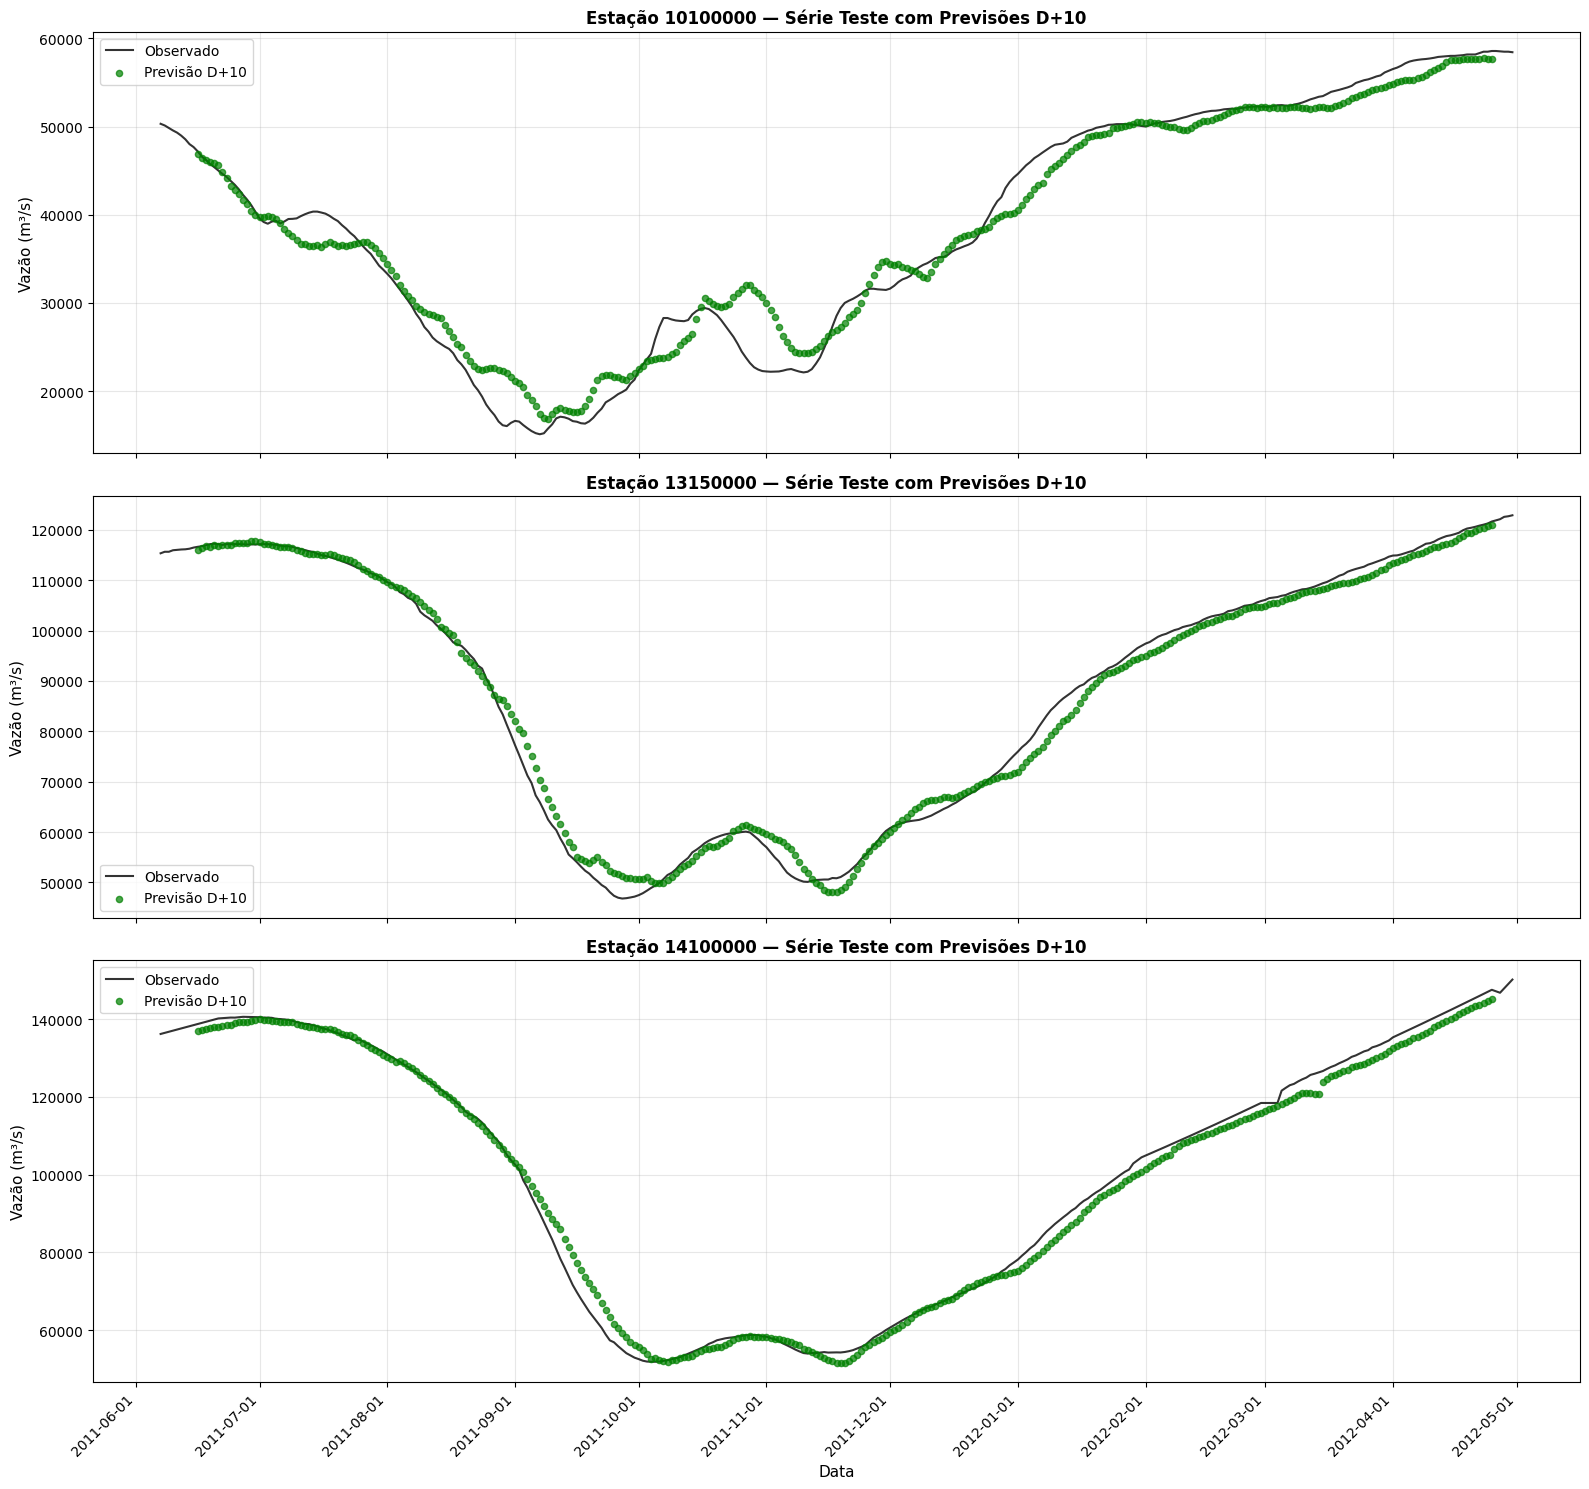

  → Criando gráfico D+11...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d11.png


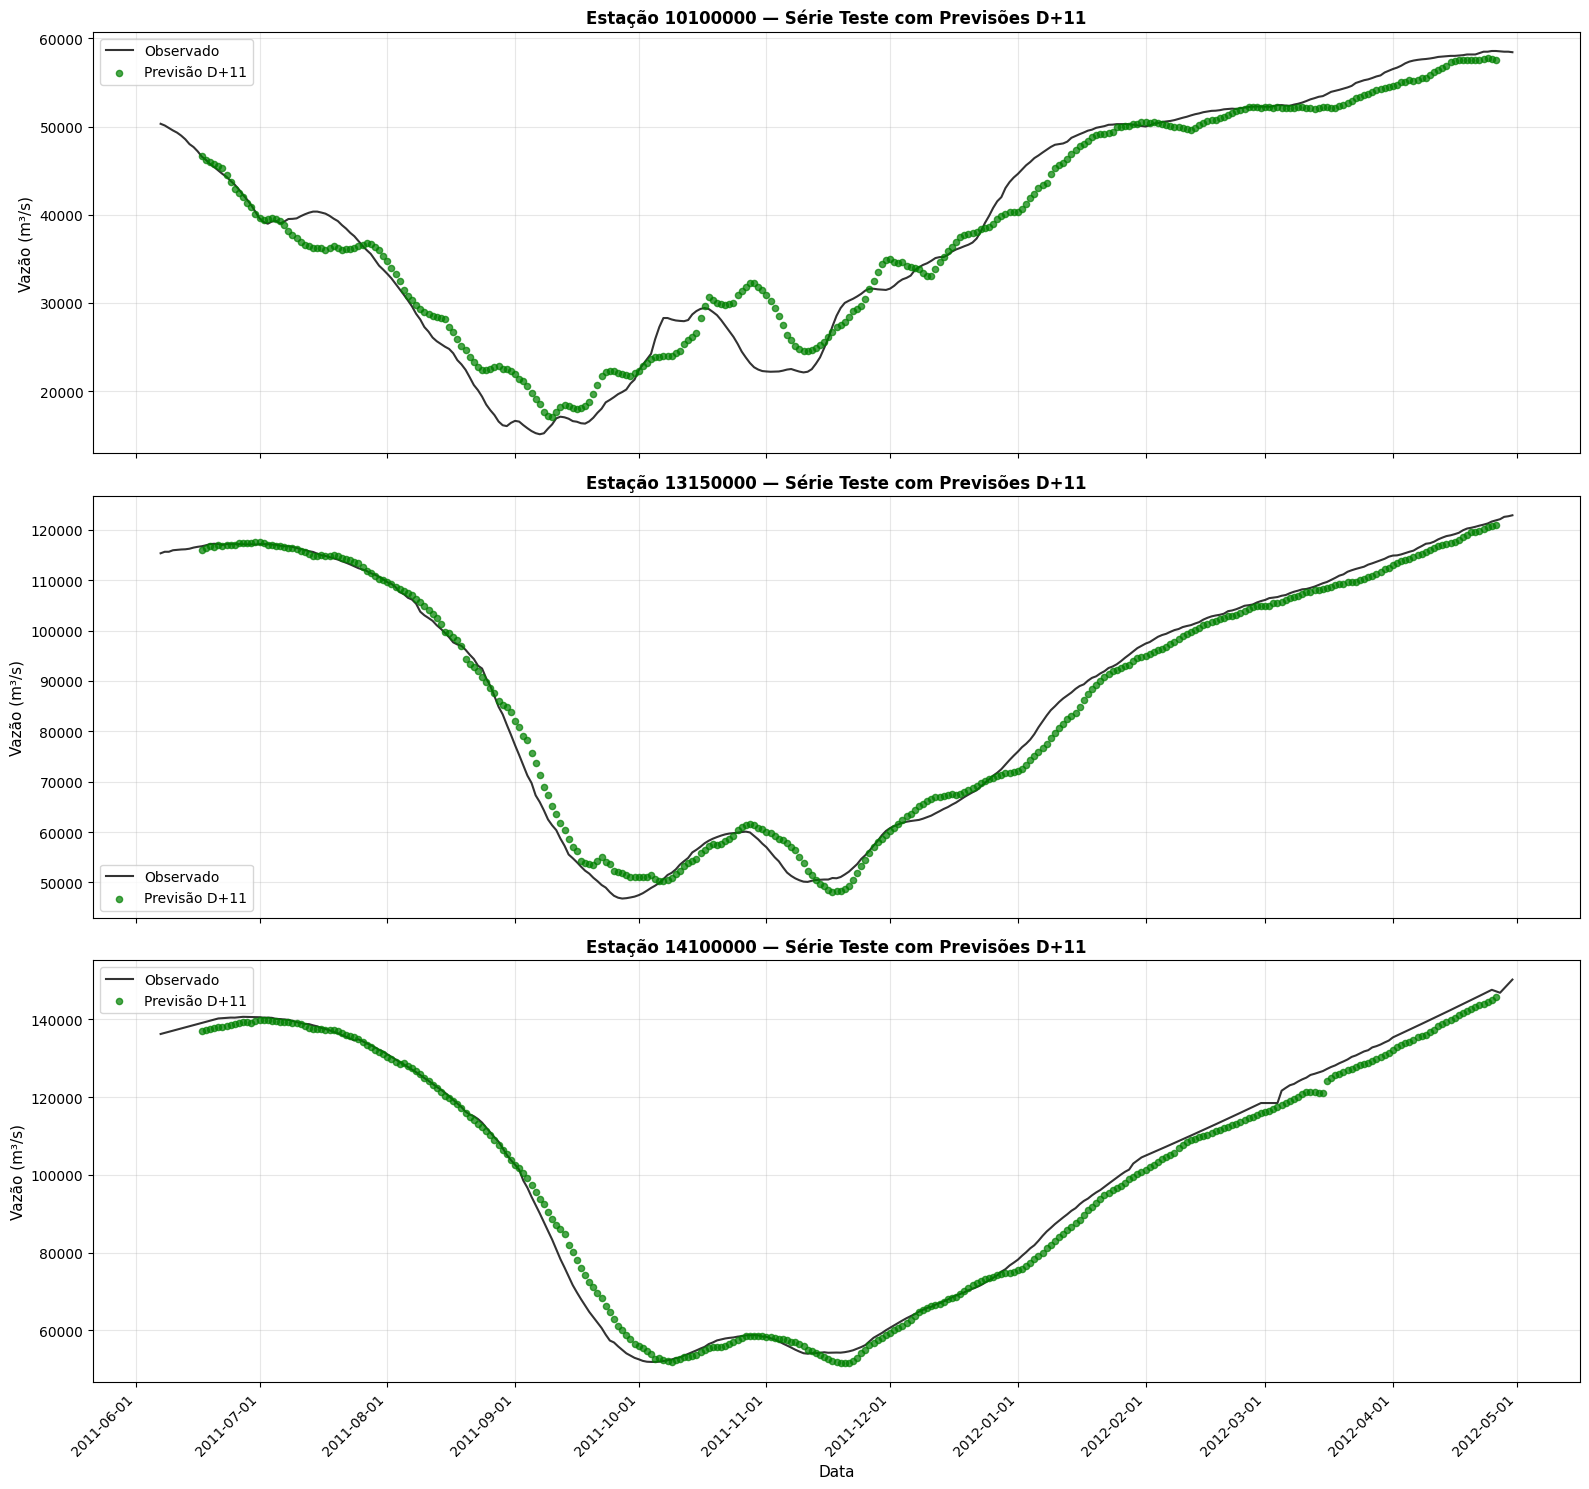

  → Criando gráfico D+12...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d12.png


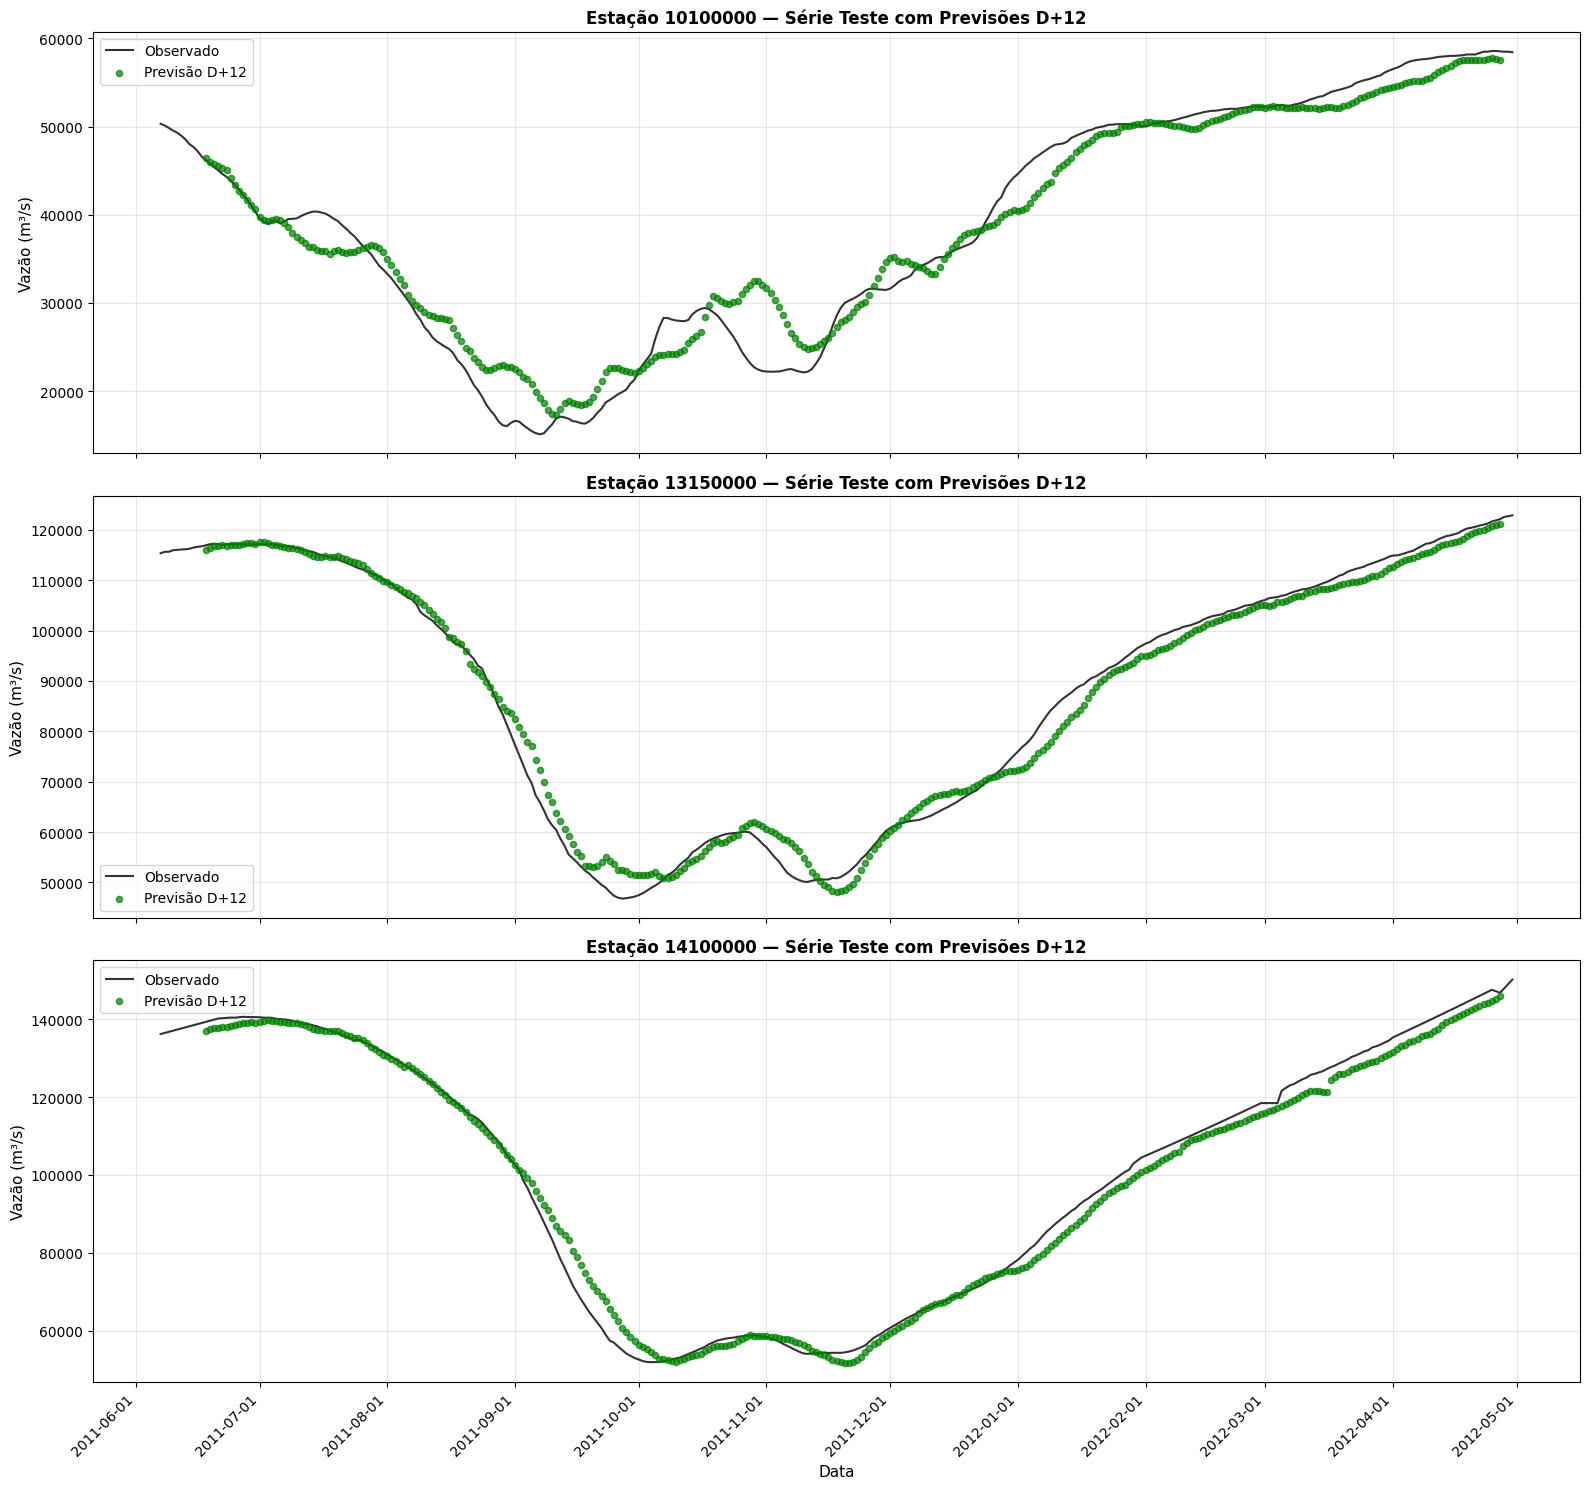

  → Criando gráfico D+13...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d13.png


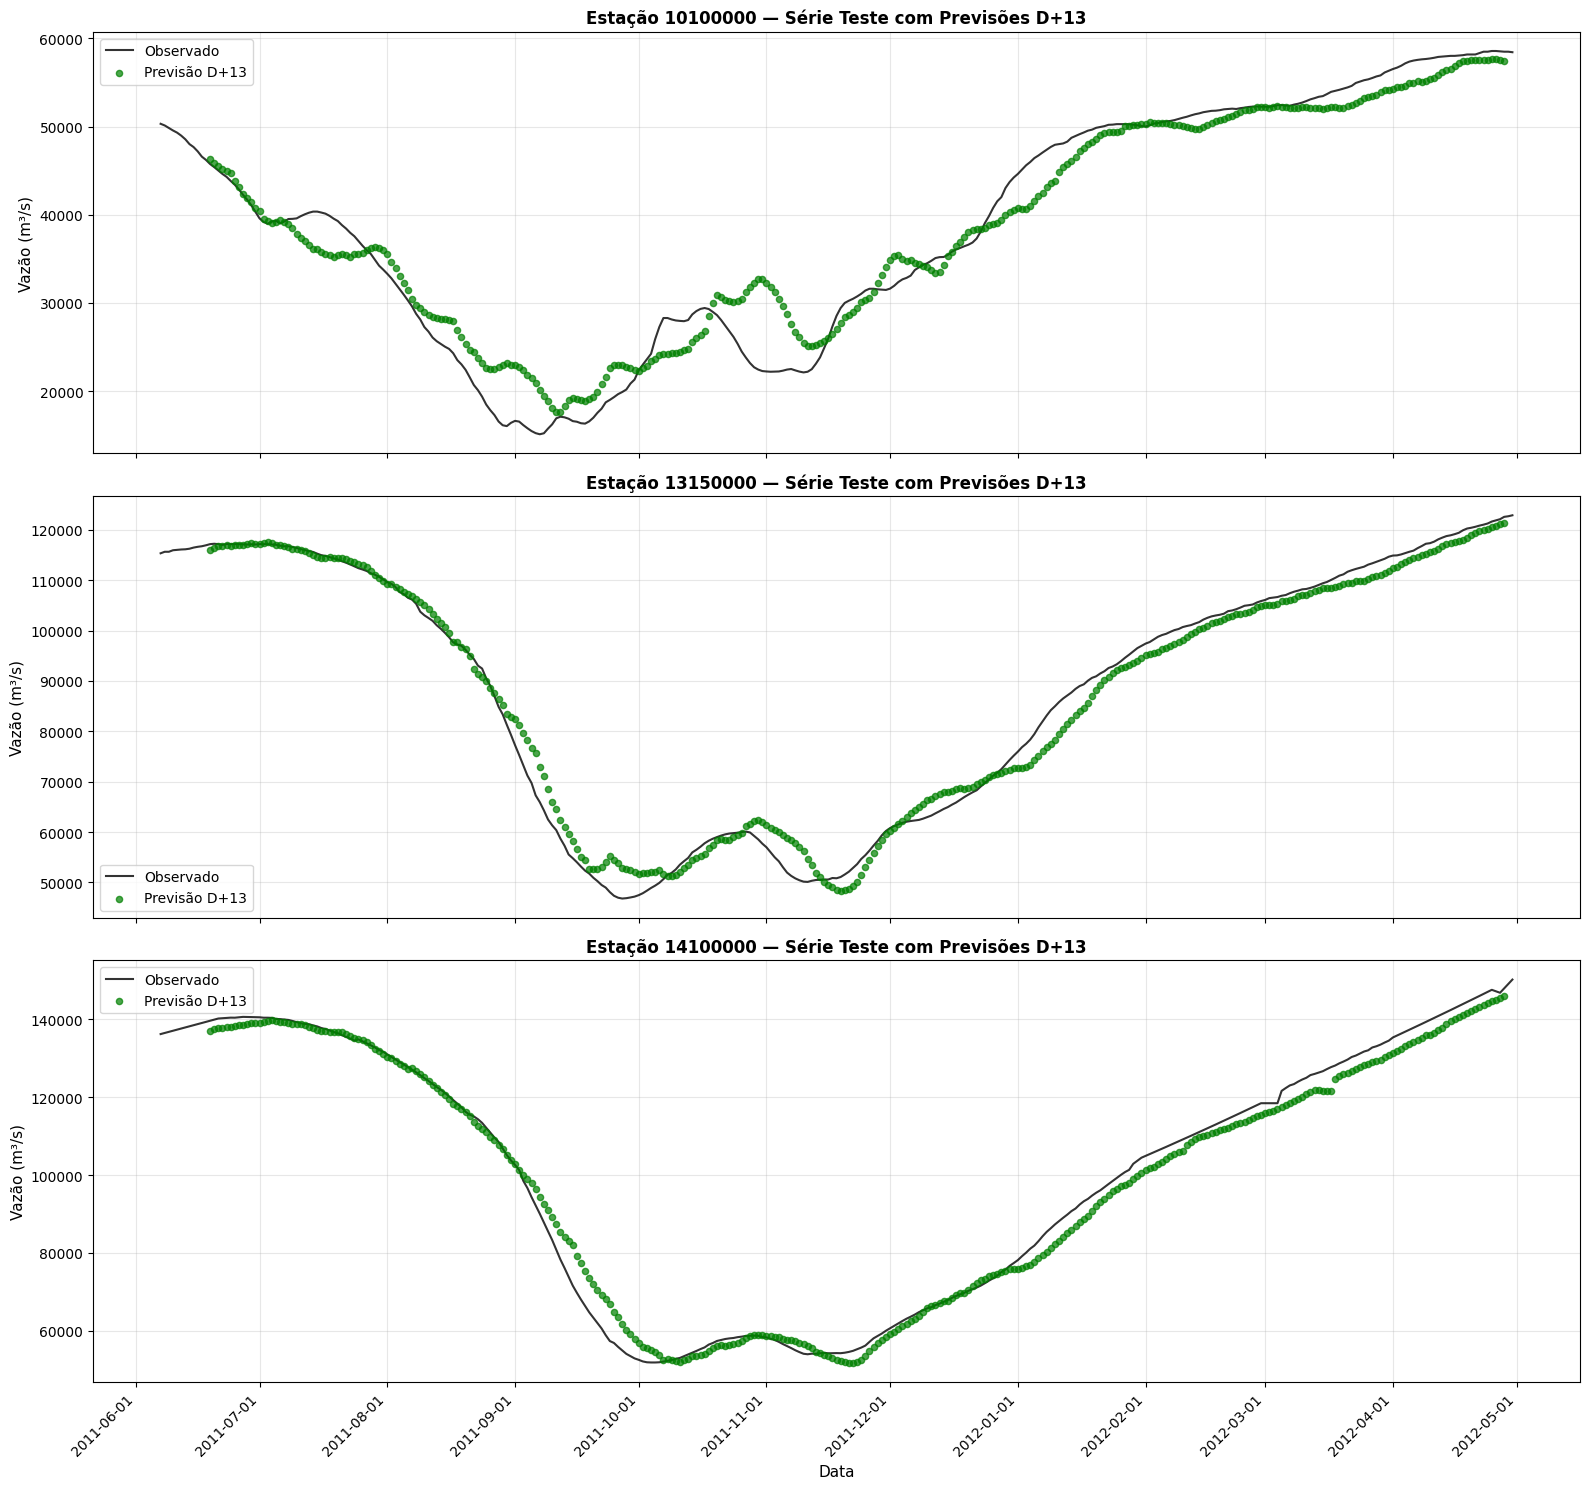

  → Criando gráfico D+14...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d14.png


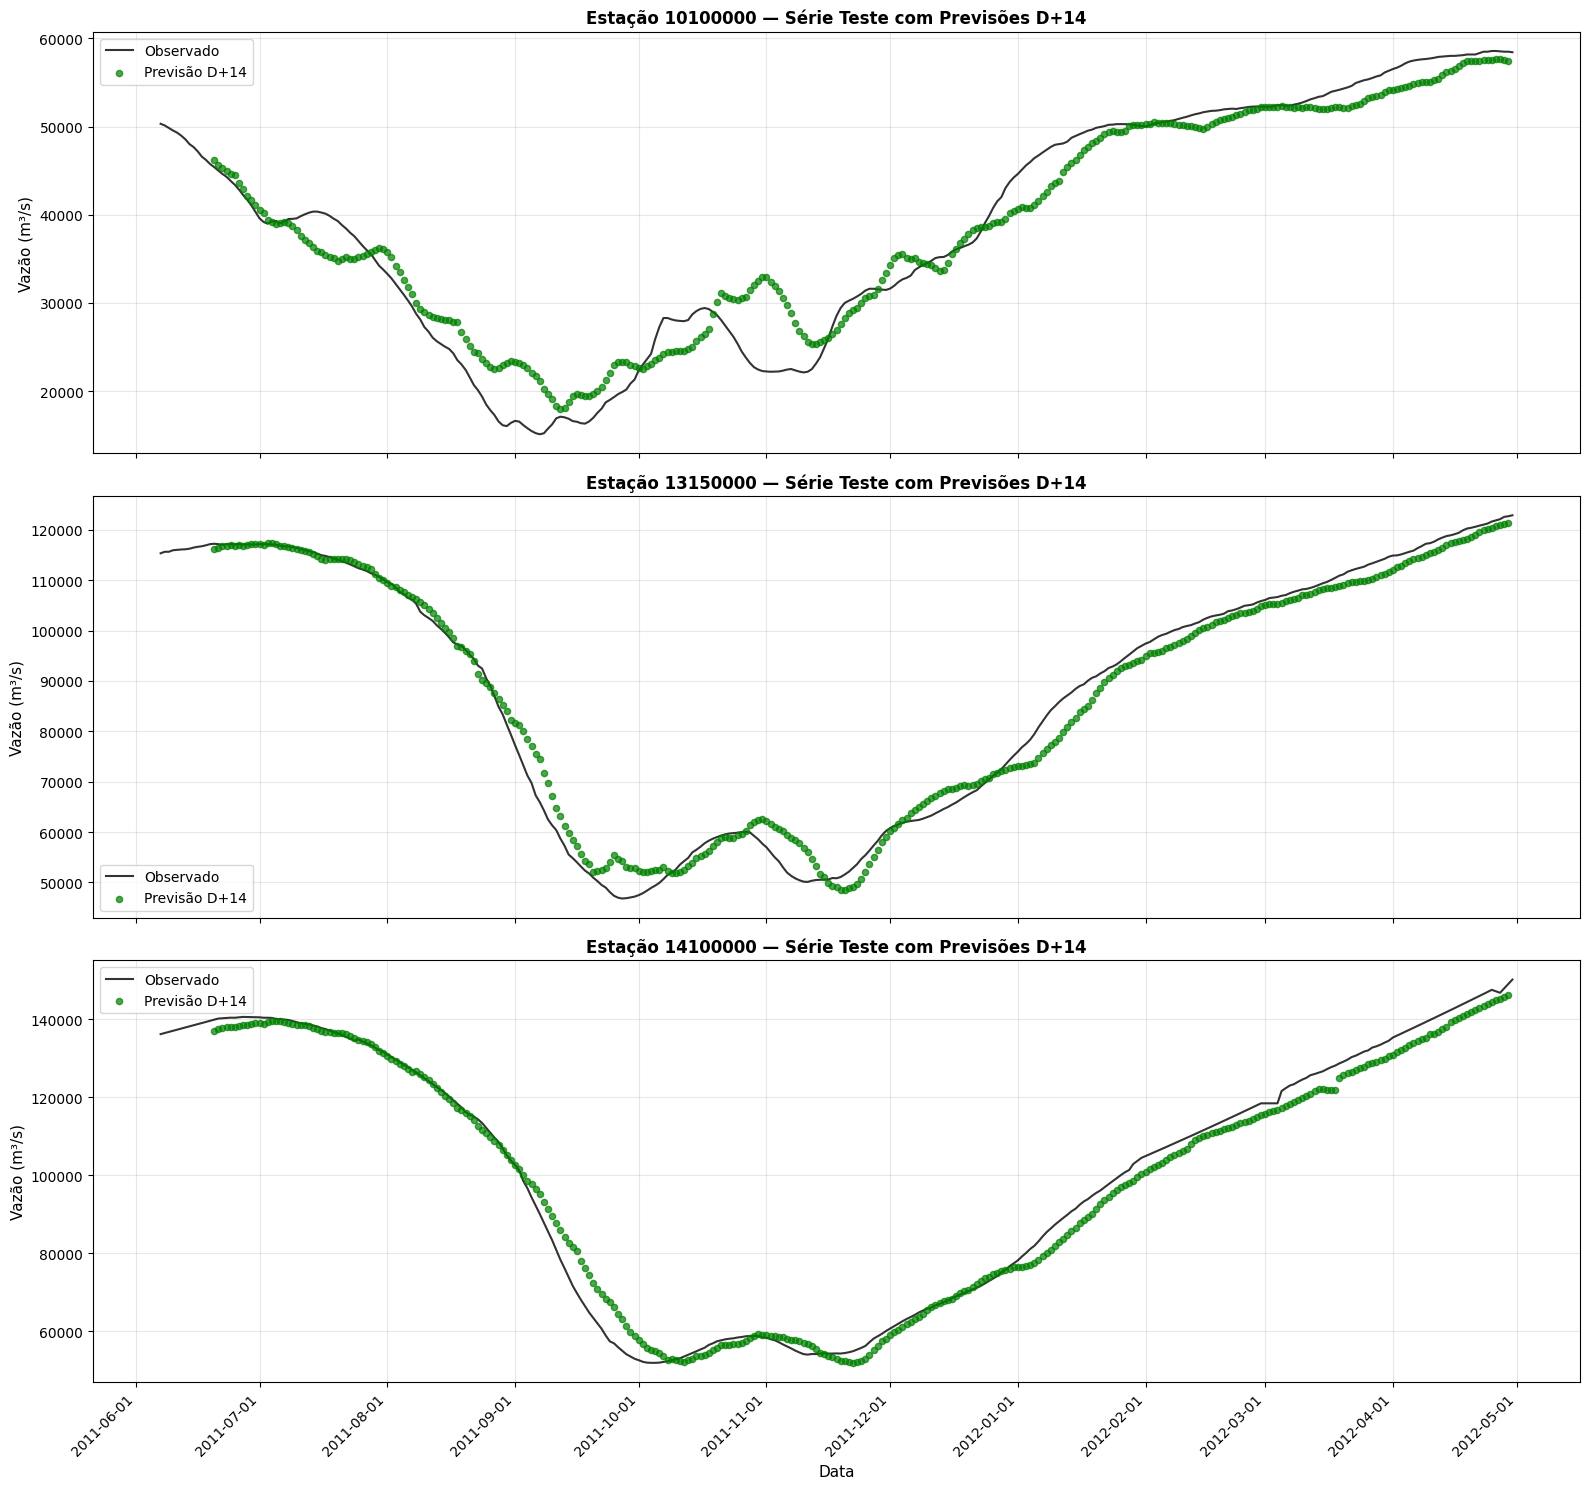

  → Criando gráfico D+15...
💾 Salvo: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_027_Improve_model_performance_exp_27_diagnostic_base_exp22\predictions_test\plots\test_d15.png


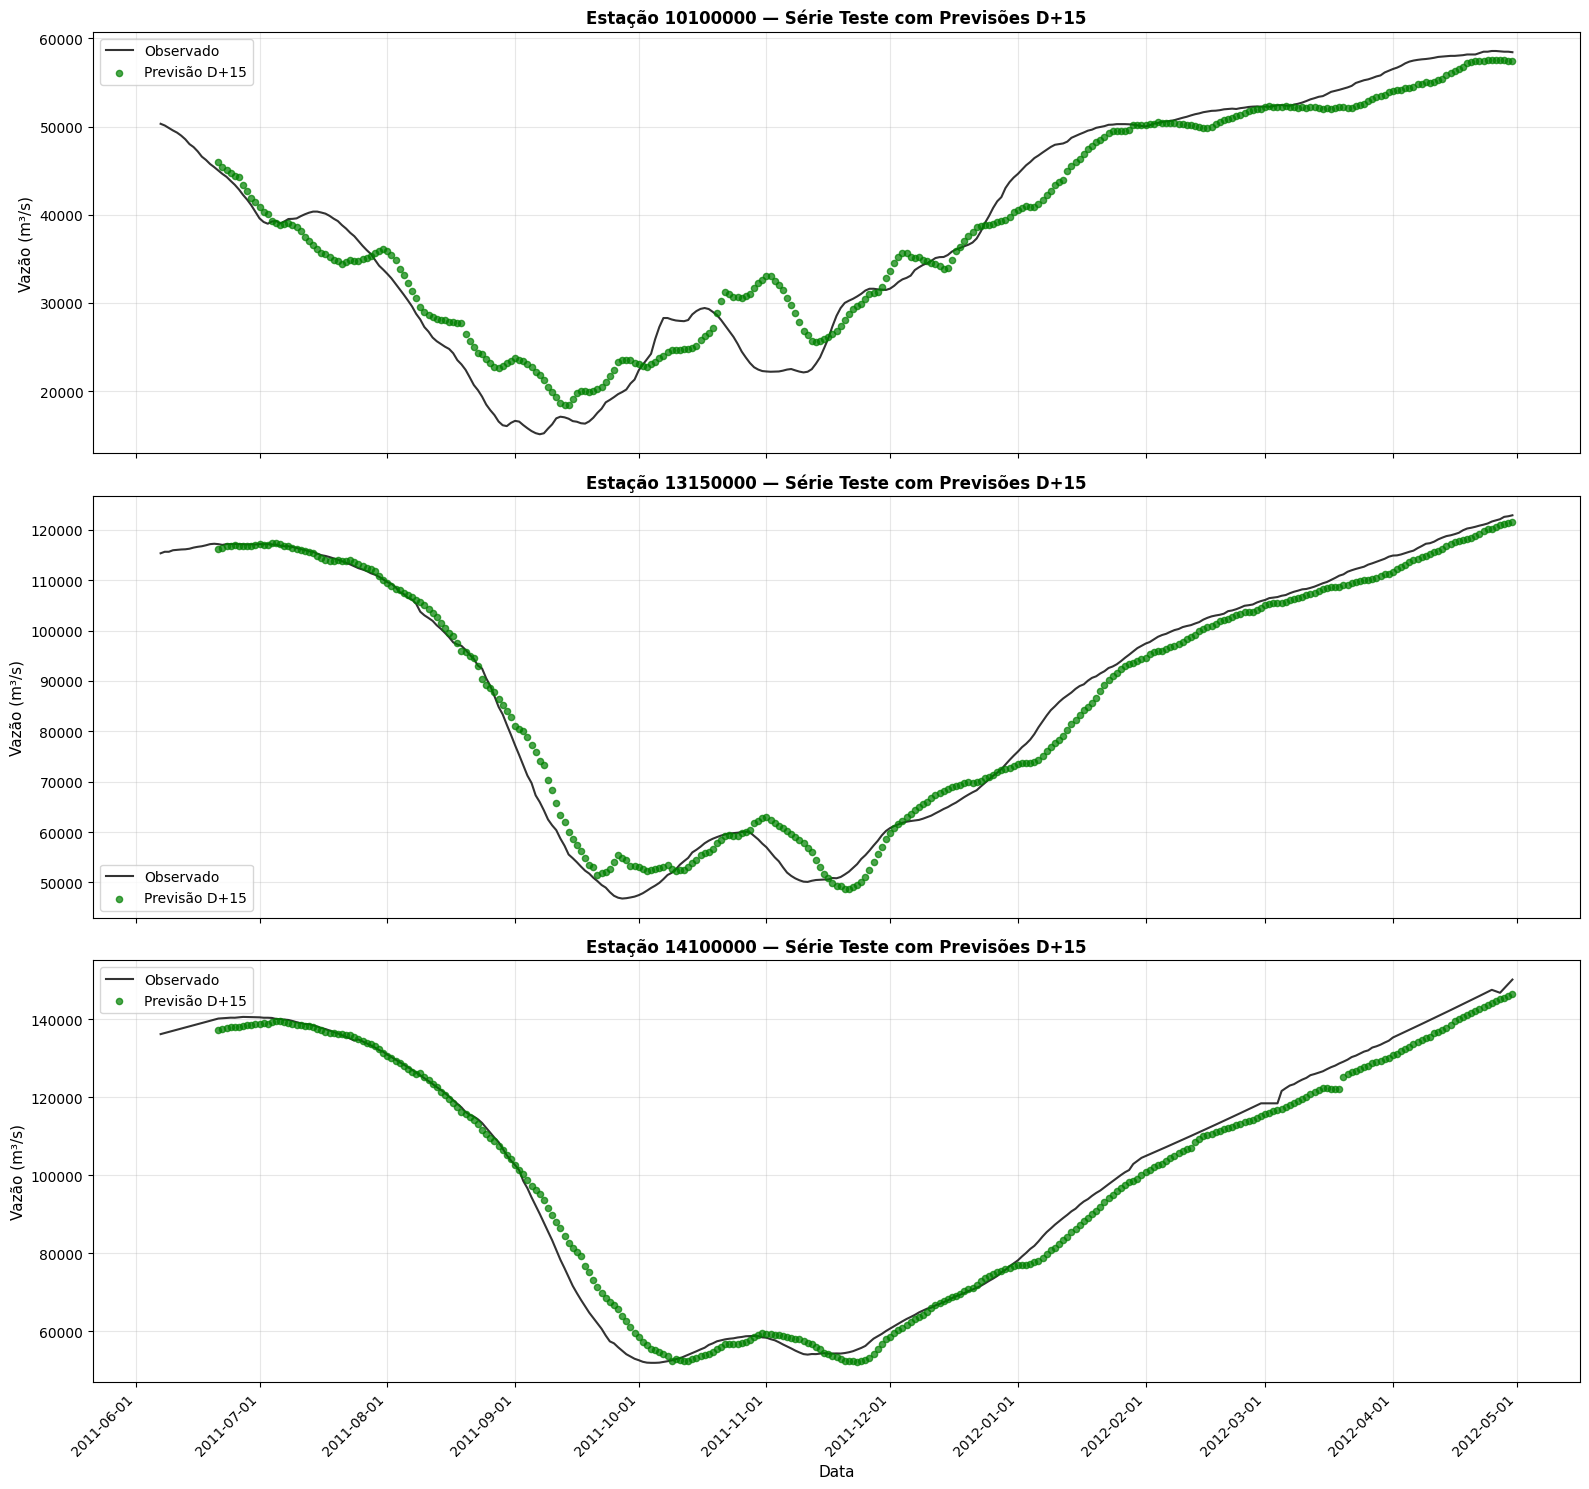


✅ Total de 16 gráficos criados!


In [18]:
figs_test = plot_forecast_horizons_analysis(
    preds=preds,
    obs=obs,
    stations=stations,
    forecast_dates=dates,
    df=combined_df,
    mode="test",
    show=True,
    save=True,
    #save_path=None,
    dpi=150 # Mostra no notebook
)

### Diagnóstico

delta: mean=0.0040  std=0.0206  %neg=32.5%  %pos=67.5%
gate:  mean=0.235  min=0.160  max=0.250


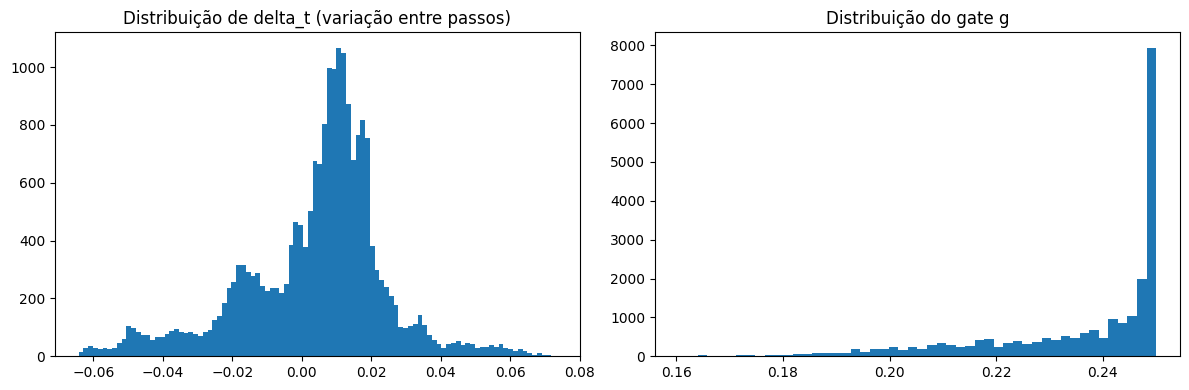

In [9]:
### Avaliando deltas e gates

from src.utils.data_utils import move_sample_to_device
# Criar loader temporário para diagnóstico
from torch.utils.data import DataLoader

diag_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=custom_collate_fn
)

model.eval()
all_deltas = []
all_gates = []

with torch.no_grad():
    for batch in diag_loader:
        b = move_sample_to_device(batch, DEVICE)
        preds, mask, g_seq = model(b, 0.0, meta["decoder_history"], meta["decoder_horizon"])
        
        # Delta real: variação entre passos consecutivos das previsões
        delta = preds[:, 1:, :] - preds[:, :-1, :]
        all_deltas.append(delta.cpu().numpy())
        
        if g_seq is not None:
            all_gates.append(g_seq.cpu().numpy())

deltas = np.concatenate(all_deltas).flatten()
gates  = np.concatenate(all_gates).flatten()

print(f"delta: mean={deltas.mean():.4f}  std={deltas.std():.4f}  "
      f"%neg={(deltas<0).mean()*100:.1f}%  %pos={(deltas>0).mean()*100:.1f}%")
print(f"gate:  mean={gates.mean():.3f}  min={gates.min():.3f}  max={gates.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deltas, bins=100)
axes[0].set_title("Distribuição de delta_t (variação entre passos)")
axes[1].hist(gates, bins=50)
axes[1].set_title("Distribuição do gate g")
plt.tight_layout()

In [10]:
# Diagnostico interno: decomposicao delta_lstm, delta_climate, gate por step
import sys

# Para Jupyter/Spyder no Windows, apenas definir encoding nas impressões
# não tente recriar o stdout, pois não funciona nesses ambientes

from src.utils.data_utils import move_sample_to_device

# Usar primeira amostra do teste (ou val_ds para comparar)
sample = test_ds[0]
batch = custom_collate_fn([sample])
batch = move_sample_to_device(batch, DEVICE)

model.eval()
with torch.no_grad():
    preds_diag, diag = model.diagnostic_forward(
        batch, meta["decoder_history"], meta["decoder_horizon"]
    )

# Imprimir decomposicao por estacao
for st_idx, st in enumerate(stations):
    scaler = meta["flow_scalers"][f"Q_{st}"]
    print(f"\n{'='*80}")
    print(f"  Estacao {st}")
    print(f"{'='*80}")
    print(f"  {'t':>3s} | {'delta_lstm':>11s} {'delta_clim':>11s} {'delta_total':>11s} | "
          f"{'gate':>6s} | {'y_prev':>10s} {'pred':>10s} {'diff':>10s}")
    print(f"  {'-'*3}-+-{'-'*11}-{'-'*11}-{'-'*11}-+-{'-'*6}-+-{'-'*10}-{'-'*10}-{'-'*10}")

    for t in range(meta["decoder_horizon"]):
        dl = diag['delta_lstm'][t][0, st_idx].item()
        dc = diag['delta_climate'][t][0, st_idx].item()
        dt = diag['delta_total'][t][0, st_idx].item()
        g = diag['gate'][t][0, st_idx].item()
        yp_scaled = diag['y_prev'][t][0, st_idx].item()
        pr_scaled = diag['pred'][t][0, st_idx].item()
        yp = scaler.inverse_transform(torch.tensor(yp_scaled)).item()
        pr = scaler.inverse_transform(torch.tensor(pr_scaled)).item()
        diff = pr - yp
        print(f"  {t:3d} | {dl:+11.4f} {dc:+11.4f} {dt:+11.4f} | "
        #print(f"  {t:3d} | {dt:+11.4f} | "
              f"{g:6.3f} | {yp:10.0f} {pr:10.0f} {diff:+10.0f}")

    print(f"\n  Resumo: ext_features mean={diag['ext_features_mean'][0][0].item():.3f}, "
          f"std={diag['ext_features_std'][0][0].item():.3f}")


  Estacao 10100000
    t |  delta_lstm  delta_clim delta_total |   gate |     y_prev       pred       diff
  ----+-------------------------------------+--------+---------------------------------
    0 |     -0.0355     +0.0000     -0.0355 |  0.186 |      50516      50178       -339
    1 |     -0.0414     +0.0000     -0.0414 |  0.217 |      50178      49797       -381
    2 |     -0.0452     +0.0000     -0.0452 |  0.212 |      49797      49378       -418
    3 |     -0.0440     +0.0000     -0.0440 |  0.201 |      49378      48965       -413
    4 |     -0.0370     +0.0000     -0.0370 |  0.242 |      48965      48636       -329
    5 |     -0.0314     +0.0000     -0.0314 |  0.228 |      48636      48352       -284
    6 |     -0.0279     +0.0000     -0.0279 |  0.186 |      48352      48086       -266
    7 |     -0.0264     +0.0000     -0.0264 |  0.203 |      48086      47839       -247
    8 |     -0.0269     +0.0000     -0.0269 |  0.226 |      47839      47595       -244
    9 |     

### Métricas

CALCULANDO LIMIARES ANUAIS PARA EVENTOS EXTREMOS
📊 Estação 10100000:
  Máximas anuais: média=53050.45, std=3322.02
    Limiar EXTREMO (alta):  Q > 56372.47 m³/s
    Limiar MODERADO (alta): 53050.45 < Q < 56372.47 m³/s
  Mínimas anuais: média=18620.11, std=7441.79
    Limiar EXTREMO (baixa):  Q < 11178.32 m³/s
    Limiar MODERADO (baixa): 11178.32 < Q < 18620.11 m³/s
📊 Estação 13150000:
  Máximas anuais: média=117338.33, std=5569.37
    Limiar EXTREMO (alta):  Q > 122907.70 m³/s
    Limiar MODERADO (alta): 117338.33 < Q < 122907.70 m³/s
  Mínimas anuais: média=49436.73, std=10090.81
    Limiar EXTREMO (baixa):  Q < 39345.92 m³/s
    Limiar MODERADO (baixa): 39345.92 < Q < 49436.73 m³/s
📊 Estação 14100000:
  Máximas anuais: média=141232.56, std=7954.80
    Limiar EXTREMO (alta):  Q > 149187.36 m³/s
    Limiar MODERADO (alta): 141232.56 < Q < 149187.36 m³/s
  Mínimas anuais: média=57054.71, std=10097.43
    Limiar EXTREMO (baixa):  Q < 46957.28 m³/s
    Limiar MODERADO (baixa): 46957.28 <

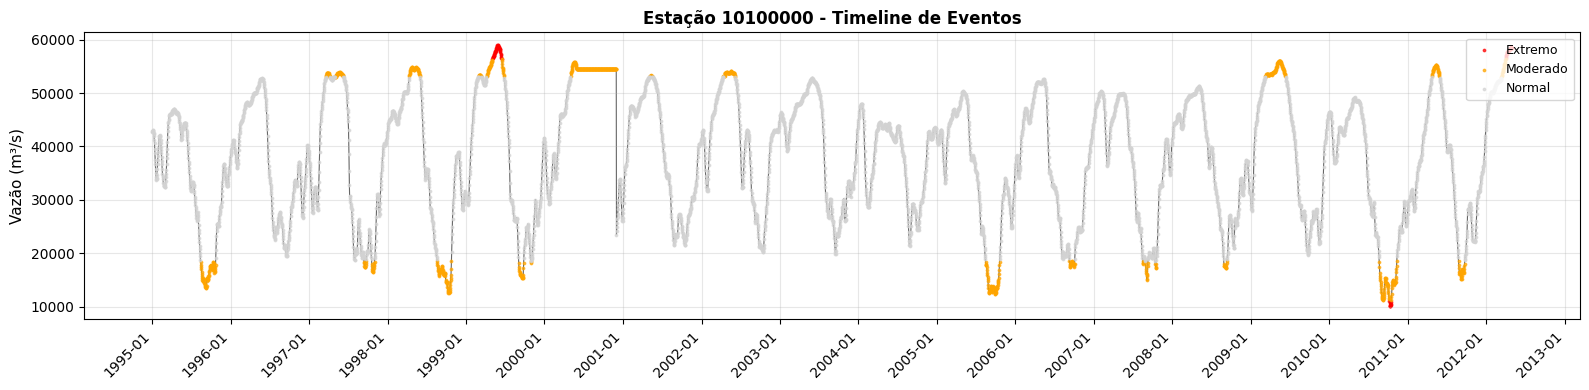

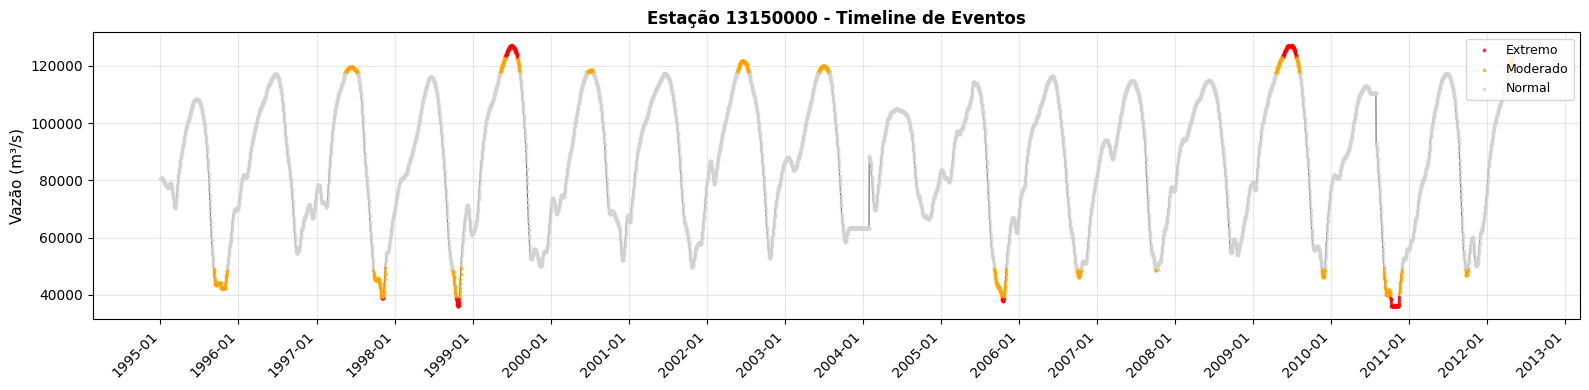

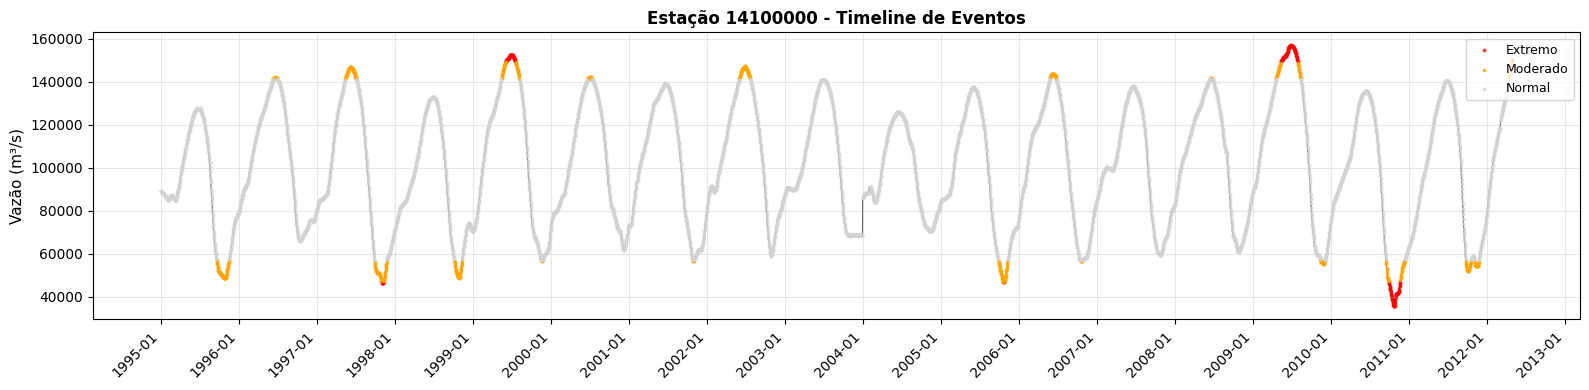

In [9]:
#  Por evento
# Obter window_indices
thresholds, classifications, window_indices = analyze_flow_extremes(
    df=combined_df,
    stations=stations,
    window_dates=dates,        # ← direto do predict_autoregressive
    flow_col_pattern="Q_{}"
)

#  Calcular métricas por tipo de evento
metrics_by_event = compute_metrics_by_event_type(
    preds=preds,
    obs=obs,
    stations=stations,
    window_indices=window_indices,
    baseline_last=baseline,
    horizon_weights=None
)

# 4. Salvar métricas
saved = save_metrics(
    metrics=metrics_by_event,
    experiment_name=experiment_name,
    filename_base="metrics_by_event"
)

💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/metrics_by_horizon.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/full_series_d1.png


c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\src\result_analysis\plots.py:47: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(S, 1, figsize=(14, 4 * S), sharex=True)


💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/forecast_idx0_20110607.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/forecast_idx1_20110608.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/forecast_idx2_20110609.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/forecast_idx3_20110610.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/forecast_idx4_20110611.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/forecast_idx5_20110612.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_gatemax/predictions_test/plots/forecast_idx6_20110613.png
💾 Plot salvo (test): exp_004_Improve_model_performance_adjustment_freerun_ga

'\n# 4. Plotar e Salvar Eventos Extremos (Máximos)\nfigs_extremes = plot_predictions_extremes(\n    preds, obs, stations, combined_df, dates,\n    n_samples=5, extreme_type=\'max\'\n)\n\nfor i, fig in enumerate(figs_extremes):\n    save_plot(fig, experiment_name, mode=MODE, name=f"extreme_max_{i}.png")\n    plt.close(fig)'

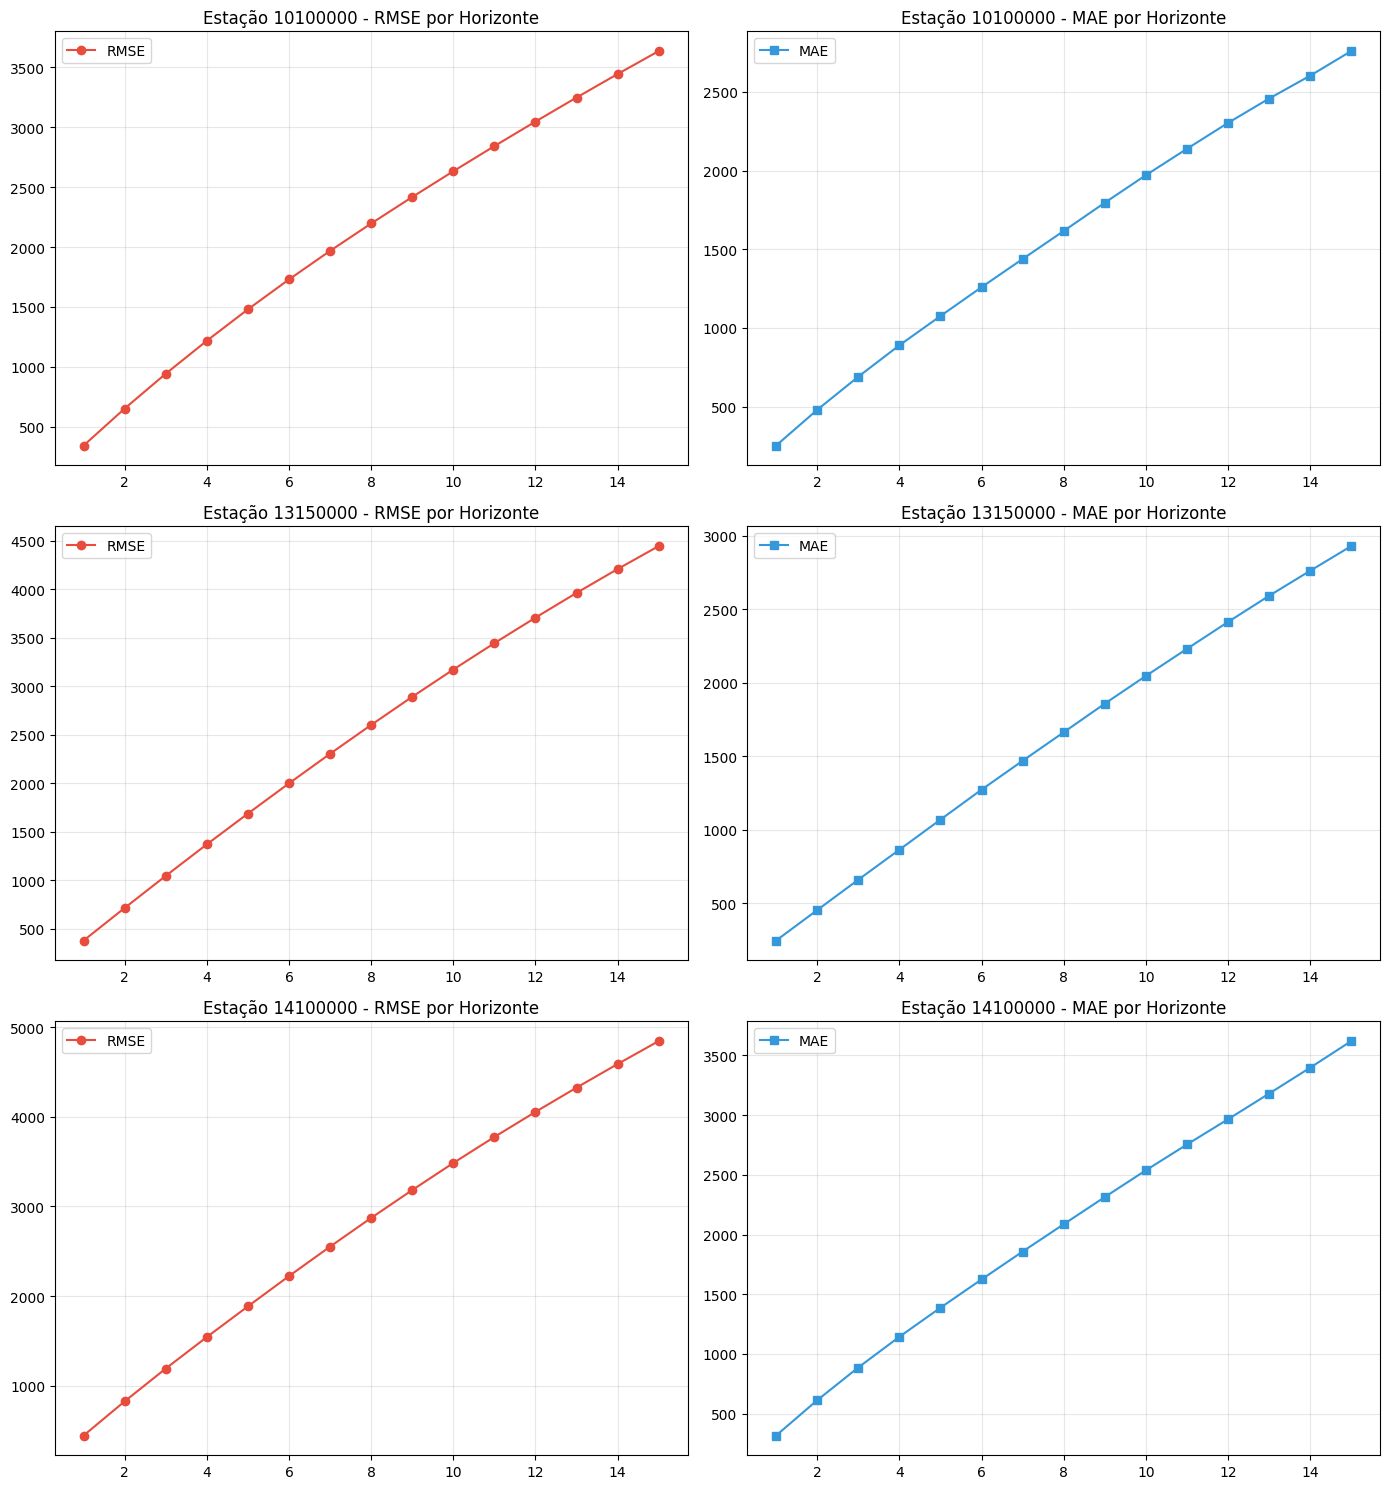

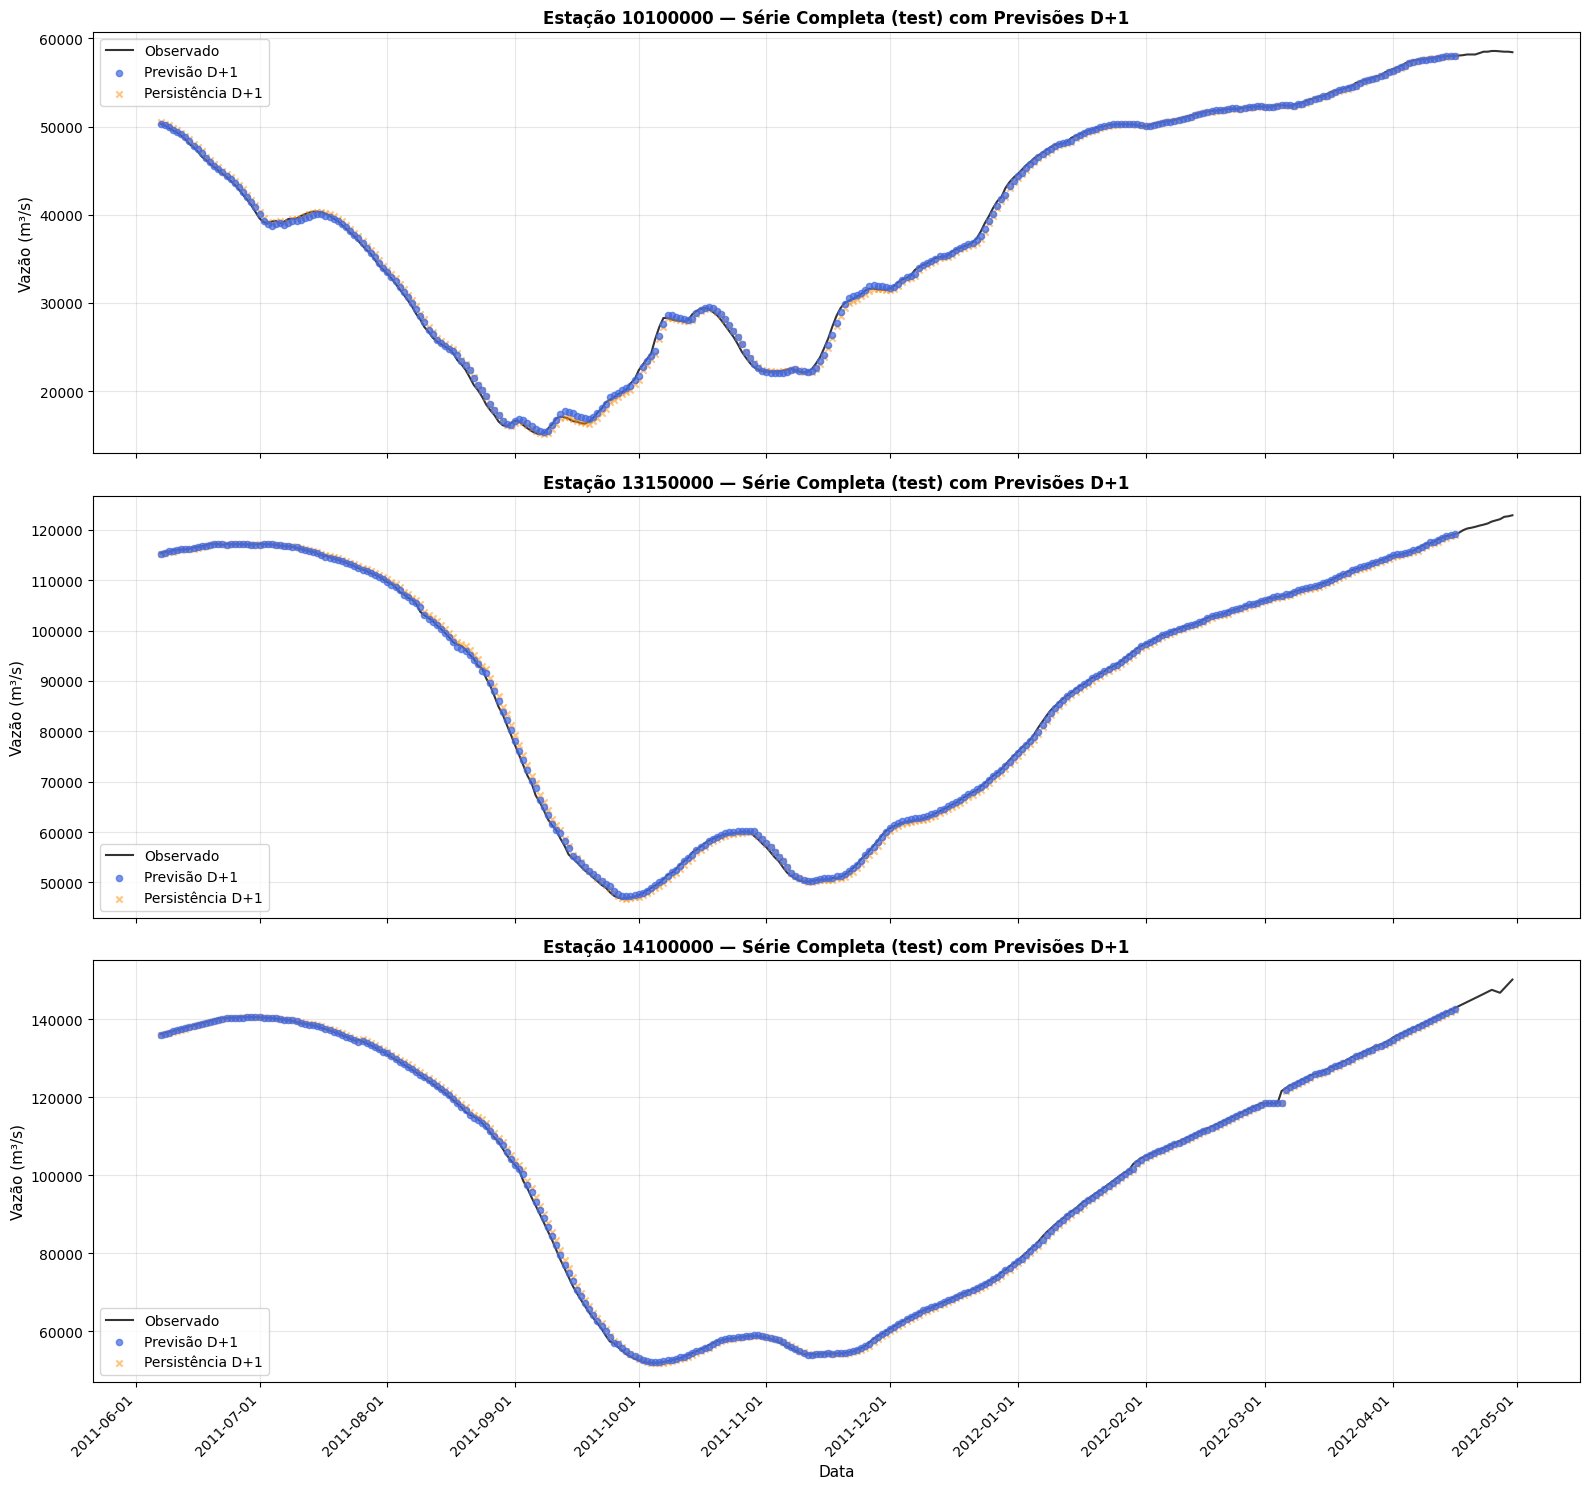

In [11]:
# --- CONFIGURAÇÕES ---
MODE = "test" # ou "operational"

# 1. Plotar e Salvar Métricas por Horizonte
fig_metrics = plot_metrics_by_horizon(
    metrics,
    stations
)
save_plot(fig_metrics, experiment_name, mode=MODE, name="metrics_by_horizon.png")


# 2. Plotar e Salvar Série Temporal D+1
fig_series = plot_full_series_with_d1_forecast(
    preds=preds,
    obs=obs,
    stations=stations,
    forecast_dates=dates,
    df=combined_df,
    period_name=MODE,
    baseline_last=baseline,
    figsize=(16, 5)
)
save_plot(fig_series, experiment_name, mode=MODE, name="full_series_d1.png")


# 3. Plotar e Salvar TODAS as janelas de previsão (ou amostras específicas)
# Se quiser todas, deixe indices=None e n_samples=None na função refatorada
figs_context = plot_predictions_with_context(
    preds, obs, stations, combined_df,dates,
    context_days=30,     # Dias de histórico para mostrar
    baseline_last=baseline,
    g_seq=g_seq,
    show=False
)


for i, fig in enumerate(figs_context):
    # Usamos a data da previsão no nome do arquivo para facilitar busca
    date_str = pd.to_datetime(dates[i]).strftime('%Y%m%d')
    save_plot(fig, experiment_name, mode=MODE, name=f"forecast_idx{i}_{date_str}.png")
    plt.close(fig) # Importante para não estourar a memória do notebook

'''
# 4. Plotar e Salvar Eventos Extremos (Máximos)
figs_extremes = plot_predictions_extremes(
    preds, obs, stations, combined_df, dates,
    n_samples=5, extreme_type='max'
)

for i, fig in enumerate(figs_extremes):
    save_plot(fig, experiment_name, mode=MODE, name=f"extreme_max_{i}.png")
    plt.close(fig)'''